# Cell 1 — Imports & setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import networkx as nx

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("All imports done ✅")

Device: cuda
All imports done ✅


# Cell 2 — Load data

In [3]:
# Load both CSVs
deliveries = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')
matches    = pd.read_csv('/content/IPL_Matches_2008_2022.csv')

print("Deliveries:", deliveries.shape)
print("Matches:", matches.shape)
print("\nDeliveries columns:", deliveries.columns.tolist())
print("Matches columns:", matches.columns.tolist())
print("\nFirst match season value:", matches['Season'].iloc[0])

Deliveries: (225954, 17)
Matches: (950, 20)

Deliveries columns: ['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler', 'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run', 'non_boundary', 'isWicketDelivery', 'player_out', 'kind', 'fielders_involved', 'BattingTeam']
Matches columns: ['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam', 'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players', 'Team2Players', 'Umpire1', 'Umpire2']

First match season value: 2022


# Cell 3 — Data cleaning


In [4]:
deliveries.columns = deliveries.columns.str.lower().str.strip()
matches.columns    = matches.columns.str.lower().str.strip()

# Fix season format: "2007/08" → 2008, "2020/21" → 2021
def parse_season(s):
    s = str(s)
    if '/' in s:
        return int(s.split('/')[0]) + 1  # "2007/08" → 2008
    return int(float(s))

matches['season'] = matches['season'].apply(parse_season)

print("Seasons:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("Total deliveries:", len(deliveries))
print("\nMissing in deliveries:\n", deliveries.isnull().sum()[deliveries.isnull().sum()>0])
print("\nMissing in matches:\n", matches.isnull().sum()[matches.isnull().sum()>0])

Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022)]
Total matches: 950
Total deliveries: 225954

Missing in deliveries:
 extra_type           213905
player_out           214803
kind                 214803
fielders_involved    217966
dtype: int64

Missing in matches:
 city                51
superover            4
winningteam          4
margin              18
method             931
player_of_match      4
dtype: int64


# Cell 4 — EDA Plot 1 & 2


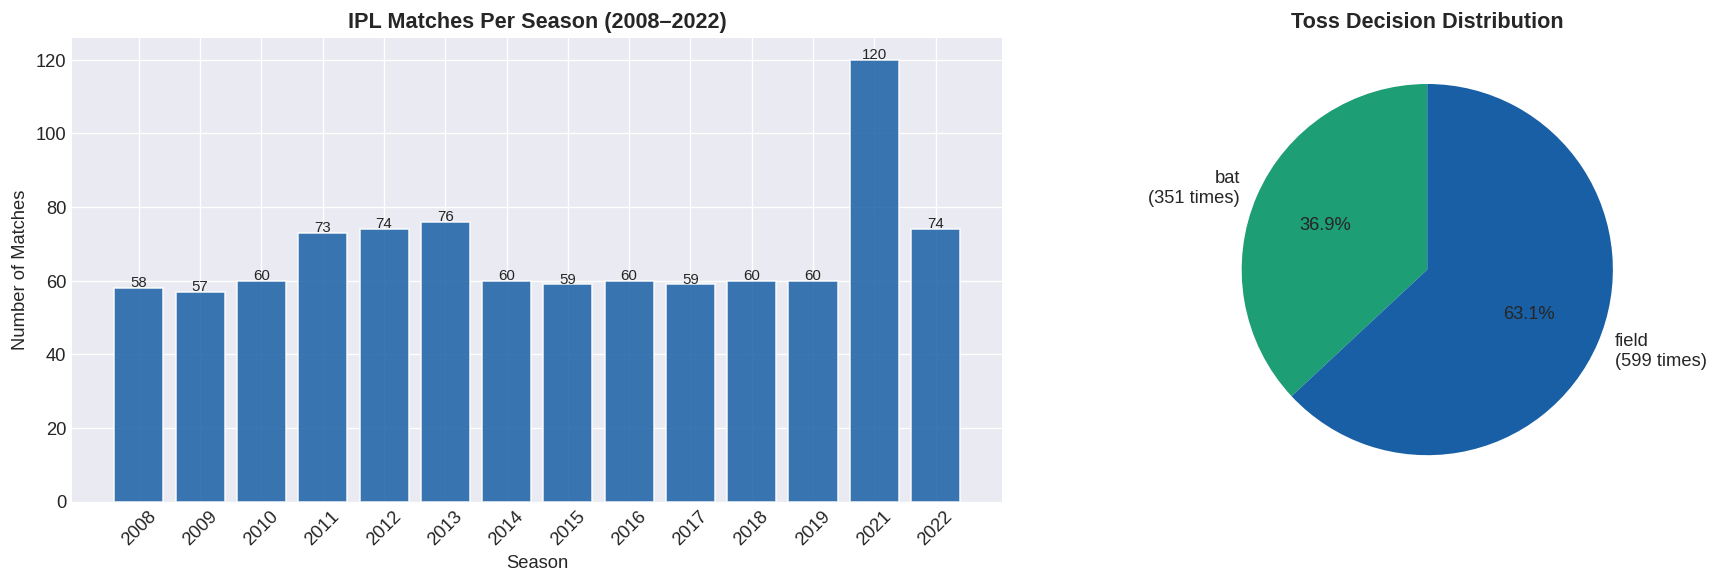

Toss winner won match: 51.5% of times


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Matches per season
season_counts = matches['season'].value_counts().sort_index()
axes[0].bar(season_counts.index.astype(str), season_counts.values,
            color='#185fa5', alpha=0.85, edgecolor='white')
axes[0].set_title('IPL Matches Per Season (2008–2022)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=9)

# Plot 2: Toss decision vs win
toss_win = matches[matches['tosswinner'] == matches['winningteam']]
toss_lose = matches[matches['tosswinner'] != matches['winningteam']]
toss_decision = matches.groupby('tossdecision')['id'].count()
axes[1].pie(toss_decision.values,
            labels=[f'{k}\n({v} times)' for k, v in toss_decision.items()],
            autopct='%1.1f%%', colors=['#1d9e75', '#185fa5'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Toss Decision Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plot1.png', bbox_inches='tight')
plt.show()
print(f"Toss winner won match: {len(toss_win)/len(matches)*100:.1f}% of times")

# Cell 5 — EDA Plot 3 & 4 (run rate & wickets)


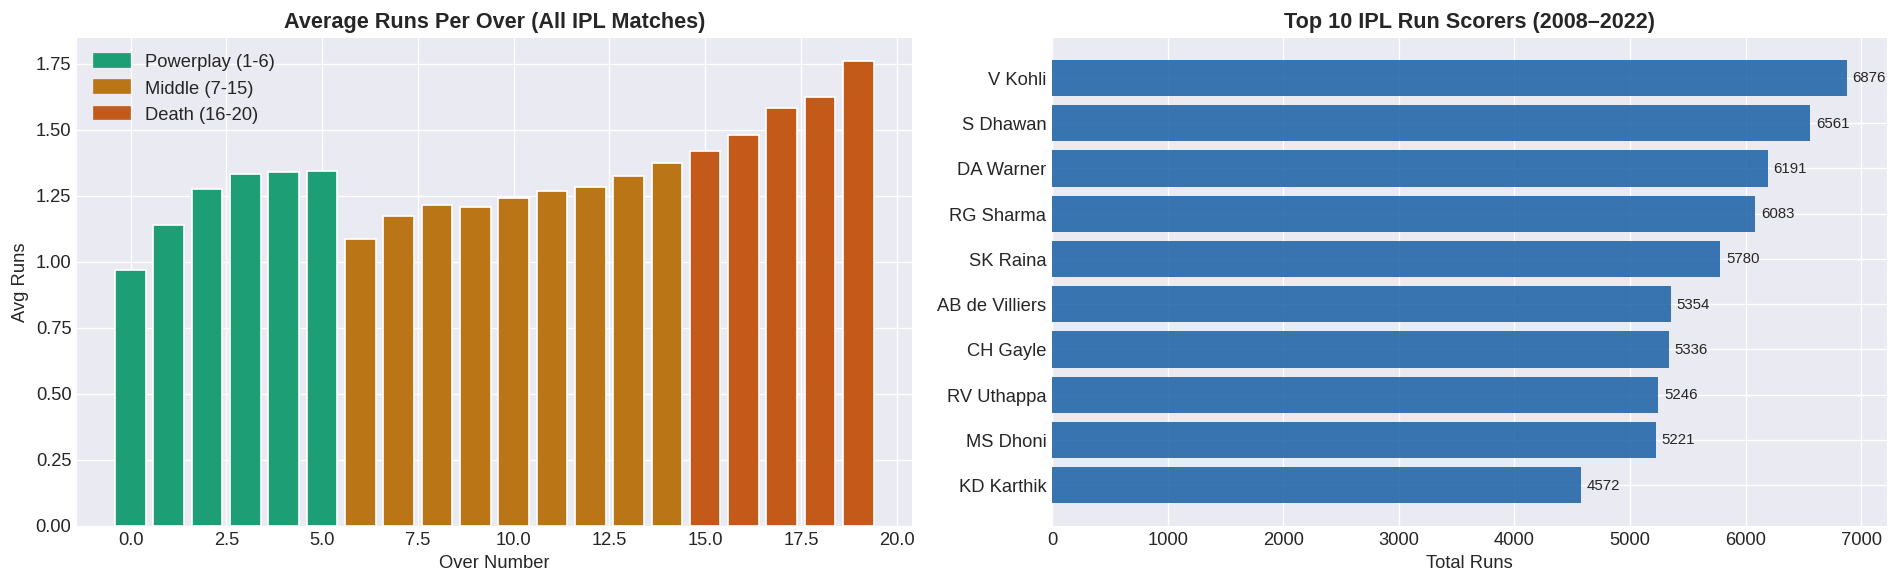

In [6]:
# Merge deliveries with matches to get winner info
df = deliveries.merge(matches[['id','winningteam','season']],
                      left_on='id', right_on='id', how='left')

# Figure out the correct column names from what printed in Cell 3
# Common column names - adjust if yours differ
run_col = 'total_run'

# Runs per over aggregated
over_runs = df.groupby('overs')[run_col].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Average runs per over (all matches)
colors = ['#1d9e75' if ov <= 5 else '#ba7517' if ov <= 14 else '#c45a1a'
          for ov in over_runs['overs']]
axes[0].bar(over_runs['overs'], over_runs[run_col], color=colors, edgecolor='white')
axes[0].set_title('Average Runs Per Over (All IPL Matches)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Over Number')
axes[0].set_ylabel('Avg Runs')
pp = mpatches.Patch(color='#1d9e75', label='Powerplay (1-6)')
mid = mpatches.Patch(color='#ba7517', label='Middle (7-15)')
death = mpatches.Patch(color='#c45a1a', label='Death (16-20)')
axes[0].legend(handles=[pp, mid, death])

# Plot 4: Top 10 run scorers
top_batsmen = (df.groupby('batter')[run_col].sum()
               .sort_values(ascending=False).head(10))
axes[1].barh(top_batsmen.index[::-1], top_batsmen.values[::-1],
             color='#185fa5', alpha=0.85)
axes[1].set_title('Top 10 IPL Run Scorers (2008–2022)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Runs')
for i, v in enumerate(top_batsmen.values[::-1]):
    axes[1].text(v + 50, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_plot2.png', bbox_inches='tight')
plt.show()

# Cell 6 — EDA Plot 5: Player partnership network


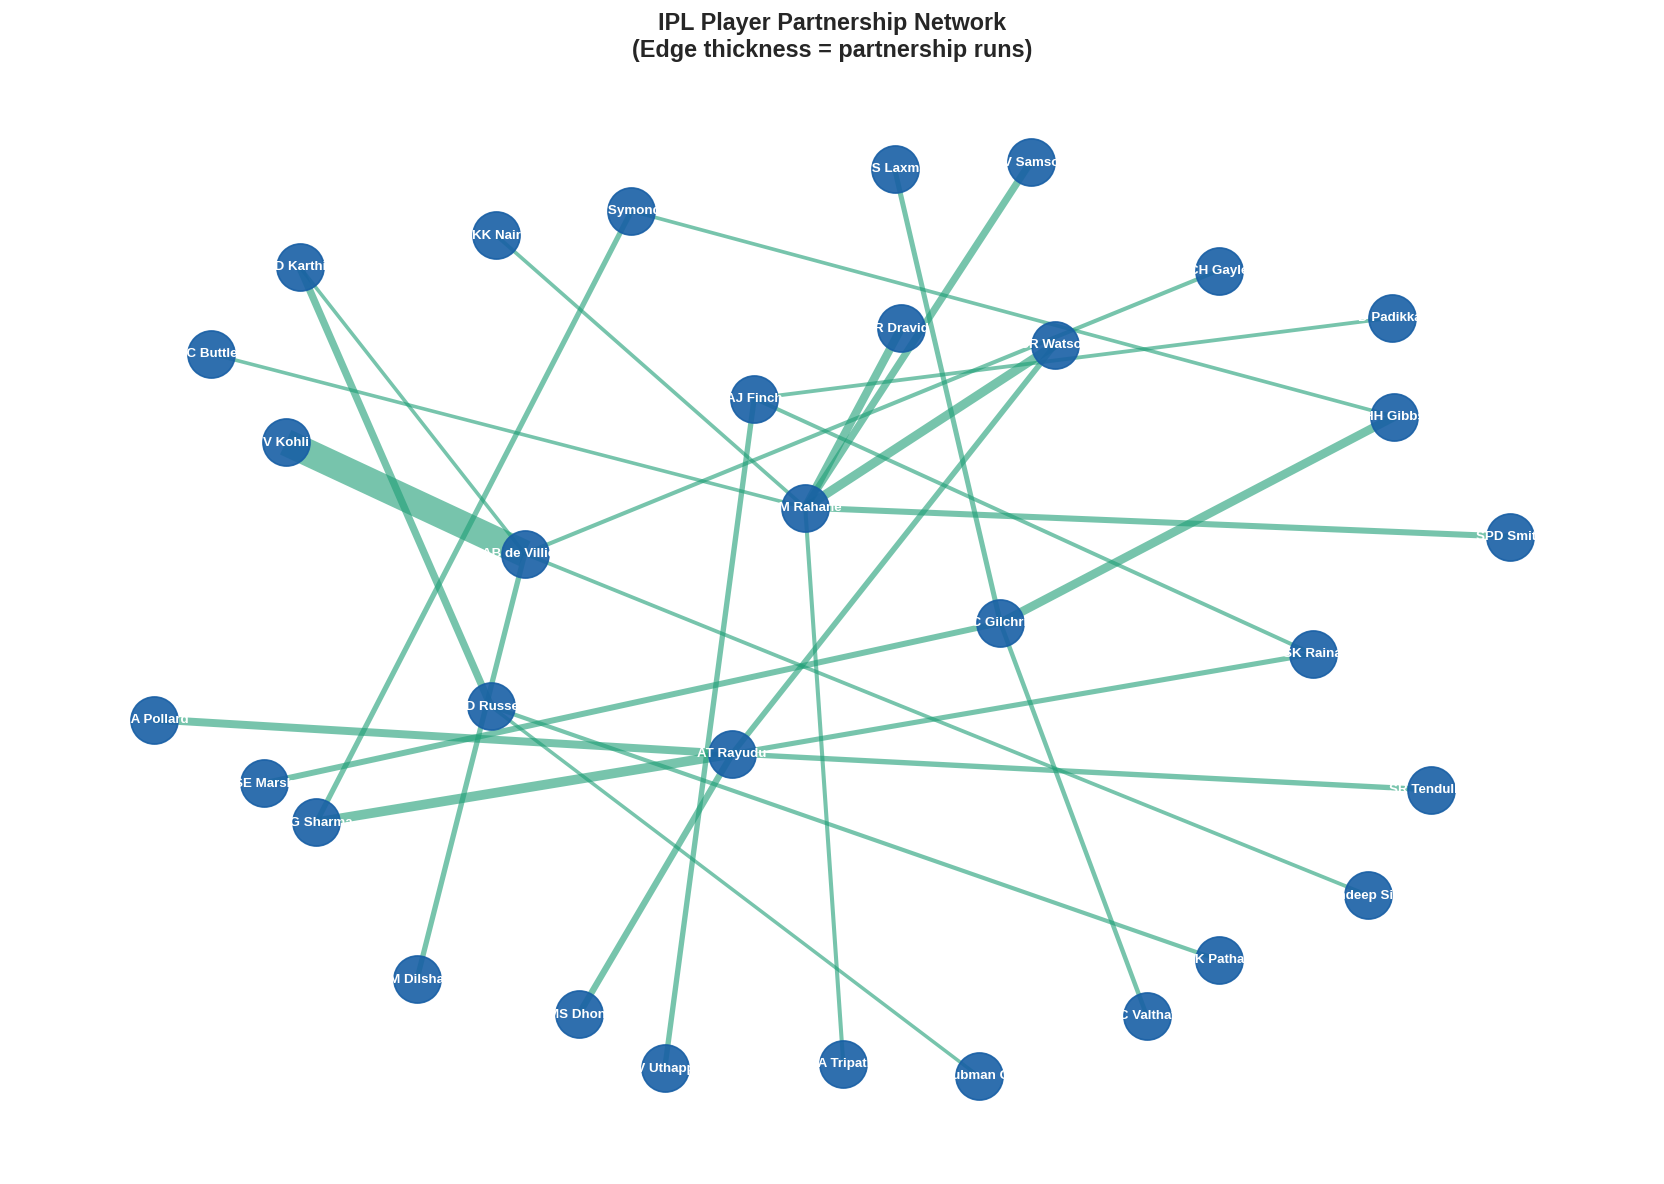

Partnership network saved ✅ — this goes straight into your proposal!


In [7]:
# Build partnership network (top partnerships by runs)
partnerships = (df.groupby(['batter', 'non-striker'])[run_col]
                .sum().reset_index()
                .rename(columns={run_col: 'partnership_runs'}))
partnerships = partnerships[partnerships['partnership_runs'] > 200].head(30)

G = nx.Graph()
for _, row in partnerships.iterrows():
    G.add_edge(row['batter'], row['non-striker'],
               weight=row['partnership_runs']/100)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color='#185fa5',
                       node_size=800, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white',
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6,
                       edge_color='#1d9e75', ax=ax)
ax.set_title('IPL Player Partnership Network\n(Edge thickness = partnership runs)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('partnership_network.png', bbox_inches='tight', dpi=150)
plt.show()
print("Partnership network saved ✅ — this goes straight into your proposal!")

# Cell 6.1 — EDA Plot: Most Successful Teams and Popular Venues

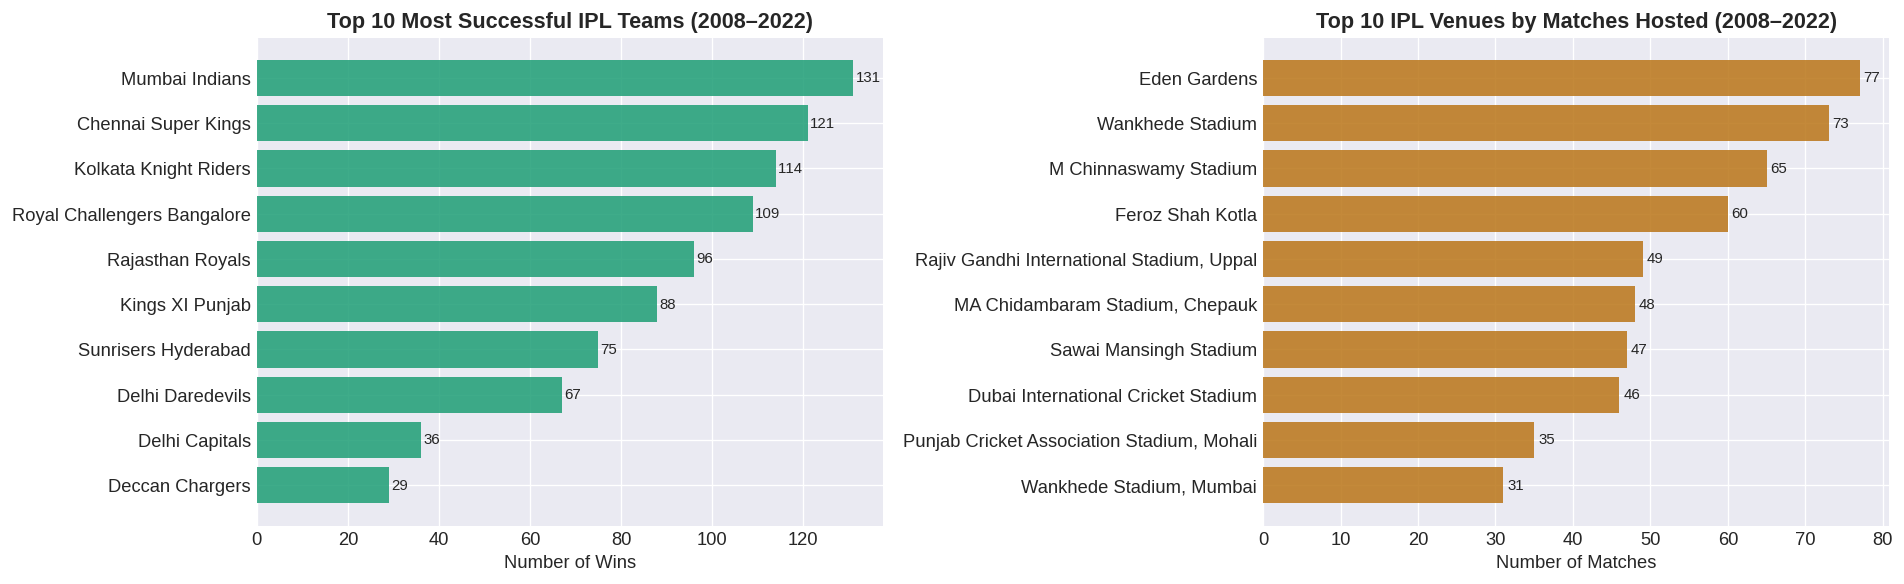

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Most Successful Teams
top_teams = matches['winningteam'].value_counts().head(10)
axes[0].barh(top_teams.index[::-1], top_teams.values[::-1],
             color='#1d9e75', alpha=0.85)
axes[0].set_title('Top 10 Most Successful IPL Teams (2008–2022)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Wins')
for i, v in enumerate(top_teams.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# Plot 2: Most Popular Venues
top_venues = matches['venue'].value_counts().head(10)
axes[1].barh(top_venues.index[::-1], top_venues.values[::-1],
             color='#ba7517', alpha=0.85)
axes[1].set_title('Top 10 IPL Venues by Matches Hosted (2008–2022)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Matches')
for i, v in enumerate(top_venues.values[::-1]):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_plot3.png', bbox_inches='tight')
plt.show()

# Cell 7 — Feature Engineering (the core analytics contribution)


In [9]:
print("Building features...")

# Sort for sequential processing
df = df.sort_values(['id', 'innings', 'overs', 'ballnumber']).reset_index(drop=True)

# === Per-ball cumulative features ===
df['cum_runs'] = df.groupby(['id','innings'])[run_col].cumsum()
df['balls_bowled'] = df.groupby(['id','innings']).cumcount() + 1
df['run_rate'] = df['cum_runs'] / (df['balls_bowled'] / 6)

# Wickets fallen
wicket_col = 'iswicketdelivery' # Corrected from player_dismissed/is_wicket
df['wicket_flag'] = df[wicket_col].fillna(0).astype(int) # Added fillna(0) to handle NaN
df['wickets_fallen'] = df.groupby(['id','innings'])['wicket_flag'].cumsum()
df['wickets_remaining'] = 10 - df['wickets_fallen']

# Match phase
df['phase'] = pd.cut(df['overs'], bins=[-1, 5, 14, 19],
                     labels=['powerplay', 'middle', 'death'])
df['phase_encoded'] = df['phase'].map({'powerplay': 0, 'middle': 1, 'death': 2})

# Balls remaining
df['balls_remaining'] = 120 - df['balls_bowled']

# Rolling run rate (last 3 overs)
df['rolling_rr_3'] = (df.groupby(['id','innings'])[run_col]
                      .transform(lambda x: x.rolling(18, min_periods=1).mean()))

# Boundary flag
df['is_boundary'] = df[run_col].apply(lambda x: 1 if x >= 4 else 0)
df['boundary_count'] = df.groupby(['id','innings'])['is_boundary'].cumsum()

# Dot ball
df['is_dot'] = (df[run_col] == 0).astype(int)
df['dot_count'] = df.groupby(['id','innings'])['is_dot'].cumsum()

# Pressure index (for 2nd innings chasing)
# Required run rate
match_1st = (df[df['innings'] == 1].groupby('id')[run_col]
             .sum().reset_index().rename(columns={run_col: 'target'}))
match_1st['target'] += 1
df = df.merge(match_1st, on='id', how='left')
df['required_rr'] = np.where(
    df['innings'] == 2,
    (df['target'] - df['cum_runs']) / (df['balls_remaining'] / 6 + 1e-5),
    0)
df['momentum'] = np.where(
    df['innings'] == 2,
    df['run_rate'] - df['required_rr'], 0)
df['pressure'] = np.where(
    (df['innings'] == 2) & (df['required_rr'] > 0),
    df['required_rr'] / (df['run_rate'] + 1e-5), 1)

# Cyclic time encoding
df['over_sin'] = np.sin(2 * np.pi * df['overs'] / 20)
df['over_cos'] = np.cos(2 * np.pi * df['overs'] / 20)

print("Features engineered ✅")
print("New columns added:", ['cum_runs','run_rate','wickets_fallen','wickets_remaining',
                              'phase_encoded','rolling_rr_3','boundary_count',
                              'dot_count','momentum','pressure','over_sin','over_cos'])
print(df[['id','innings','overs','ballnumber','run_rate',
          'wickets_remaining','momentum','pressure']].head(10))

Building features...
Features engineered ✅
New columns added: ['cum_runs', 'run_rate', 'wickets_fallen', 'wickets_remaining', 'phase_encoded', 'rolling_rr_3', 'boundary_count', 'dot_count', 'momentum', 'pressure', 'over_sin', 'over_cos']
       id  innings  overs  ballnumber  run_rate  wickets_remaining  momentum  \
0  335982        1      0           1  6.000000                 10       0.0   
1  335982        1      0           2  3.000000                 10       0.0   
2  335982        1      0           3  4.000000                 10       0.0   
3  335982        1      0           4  3.000000                 10       0.0   
4  335982        1      0           5  2.400000                 10       0.0   
5  335982        1      0           6  2.000000                 10       0.0   
6  335982        1      0           7  2.571429                 10       0.0   
7  335982        1      1           1  2.250000                 10       0.0   
8  335982        1      1           2  4.6

In [10]:
print("Creating win_label and defining FEATURES...")

# Create win_label based on whether the batting team is the winning team
df['win_label'] = (df['battingteam'] == df['winningteam']).astype(int)

# Define FEATURES list from the engineered features
FEATURES = [
    'cum_runs',
    'balls_bowled',
    'run_rate',
    'wicket_flag',
    'wickets_fallen',
    'wickets_remaining',
    'phase_encoded',
    'balls_remaining',
    'rolling_rr_3',
    'is_boundary',
    'boundary_count',
    'is_dot',
    'dot_count',
    'required_rr',
    'momentum',
    'pressure',
    'over_sin',
    'over_cos'
]

# Drop rows with NaN values that might have been introduced during feature engineering
# especially if 'winningteam' was NaN or during scaling if NaNs are present.
# We will do this after selecting columns for model_df in Cell 8.

print("FEATURES and win_label created ✅")
print(f"Number of features: {len(FEATURES)}")

Creating win_label and defining FEATURES...
FEATURES and win_label created ✅
Number of features: 18


# Cell 8 — Create Win Label + Train/Val/Test Split


In [11]:
model_df = df[FEATURES + ['win_label', 'id', 'innings', 'season', 'batter', 'bowler']].dropna()
print(f"Dataset size : {model_df.shape}")
print(f"Win label:\n{model_df['win_label'].value_counts()}")

# Chronological split
train_df = model_df[model_df['season'] <= 2019].reset_index(drop=True)
val_df   = model_df[model_df['season'] == 2021].reset_index(drop=True)
test_df  = model_df[model_df['season'] == 2022].reset_index(drop=True)

print(f"\nTrain : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")

# Scale features only
scaler  = StandardScaler()
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = scaler.transform(val_df[FEATURES])
test_df[FEATURES]  = scaler.transform(test_df[FEATURES])

print("Done ✅")

Dataset size : (225954, 24)
Win label:
win_label
0    115547
1    110407
Name: count, dtype: int64

Train : 179,058 | Val : 28,984 | Test : 17,912
Done ✅


# Cell 9 — PyTorch Dataset + DataLoader


In [12]:
SEQ_LEN = 50

class CricketDataset(Dataset):
    """Creates sequences WITHIN each match-inning only.
       Never crosses match boundaries."""
    def __init__(self, df_subset, feature_cols, seq_len=SEQ_LEN):
        self.sequences = []
        self.labels    = []

        groups = df_subset.groupby(['id', 'innings'])
        for (mid, inn), grp in groups:
            grp = grp.reset_index(drop=True)
            X = grp[feature_cols].values.astype(np.float32)
            y = grp['win_label'].values.astype(np.float32)

            # Only use innings with enough balls
            if len(X) < seq_len:
                continue

            for i in range(len(X) - seq_len + 1):
                self.sequences.append(X[i : i + seq_len])
                self.labels.append(y[i + seq_len - 1])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels    = np.array(self.labels,    dtype=np.float32)
        print(f"  Built {len(self.sequences):,} sequences from {len(groups)} innings")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.sequences[idx]),
            torch.tensor(self.labels[idx])
        )

print("Building datasets (respecting match boundaries)...")
train_ds = CricketDataset(train_df, FEATURES)
val_ds   = CricketDataset(val_df,   FEATURES)
test_ds  = CricketDataset(test_df,  FEATURES)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, drop_last=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
print(f"Sample shape  : {next(iter(train_loader))[0].shape}")
print("DataLoaders ready ✅")

Building datasets (respecting match boundaries)...
  Built 105,159 sequences from 1528 innings
  Built 17,163 sequences from 252 innings
  Built 10,660 sequences from 148 innings

Train batches : 410
Val   batches : 68
Test  batches : 42
Sample shape  : torch.Size([256, 50, 18])
DataLoaders ready ✅


# Cell 10 — BiLSTM Model (Branch B — baseline)


In [13]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=len(FEATURES), hidden=256, # Increased hidden from 128 to 256
                 num_layers=2, dropout=0.3): # Reduced dropout from 0.4 to 0.3
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout)
        self.norm = nn.LayerNorm(hidden * 2)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(hidden * 2, 64)
        self.fc2  = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Take the output from the last timestep
        out = self.norm(out)
        out = self.drop(F.relu(self.fc1(out)))
        return torch.sigmoid(self.fc2(out)).squeeze(1)

model = BiLSTMModel(input_dim=len(FEATURES)).to(device)
params = sum(p.numel() for p in model.parameters())
print(f"BiLSTM ✅  |  Parameters: {params:,}")
print(model)

BiLSTM ✅  |  Parameters: 2,176,129
BiLSTMModel(
  (lstm): LSTM(18, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=512, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


# Cell 11 — Training loop


In [14]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3,
                                                        factor=0.5)
criterion = nn.BCELoss()

EPOCHS = 30
train_losses, val_losses, val_accs = [], [], []
best_val_acc  = 0
best_model_state = None
patience_count = 0
PATIENCE = 7   # early stopping

print("Training BiLSTM (boundary-aware)...\n")
for epoch in range(EPOCHS):
    # Train
    model.train()
    t_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()

    # Validate
    model.eval()
    v_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            probs = model(Xb)
            v_loss += criterion(probs, yb).item()
            preds_all.extend((probs > 0.5).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    val_acc  = accuracy_score(labels_all, preds_all)
    tl = t_loss / len(train_loader)
    vl = v_loss  / len(val_loader)
    train_losses.append(tl)
    val_losses.append(vl)
    val_accs.append(val_acc)
    scheduler.step(vl)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(f"Ep {epoch+1:02d}/{EPOCHS} | "
          f"TrLoss:{tl:.4f} VaLoss:{vl:.4f} VaAcc:{val_acc:.4f}"
          f"{'  ⭐ best' if is_best else ''}"
          f"{'  ⏳ patience '+str(patience_count) if not is_best else ''}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.4f} ✅")
torch.save(best_model_state, 'best_bilstm.pt')

Training BiLSTM (boundary-aware)...

Ep 01/30 | TrLoss:0.5996 VaLoss:0.5780 VaAcc:0.6857  ⭐ best
Ep 02/30 | TrLoss:0.5897 VaLoss:0.5811 VaAcc:0.6822  ⏳ patience 1
Ep 03/30 | TrLoss:0.5775 VaLoss:0.5858 VaAcc:0.6808  ⏳ patience 2
Ep 04/30 | TrLoss:0.5590 VaLoss:0.6258 VaAcc:0.6699  ⏳ patience 3
Ep 05/30 | TrLoss:0.5211 VaLoss:0.6569 VaAcc:0.6558  ⏳ patience 4
Ep 06/30 | TrLoss:0.4472 VaLoss:0.8885 VaAcc:0.6065  ⏳ patience 5
Ep 07/30 | TrLoss:0.3542 VaLoss:1.1609 VaAcc:0.5974  ⏳ patience 6
Ep 08/30 | TrLoss:0.2538 VaLoss:1.4193 VaAcc:0.5828  ⏳ patience 7

Early stopping at epoch 8

Best Val Accuracy: 0.6857 ✅


# Cell 12 — Training curves + test evaluation


    BiLSTM BASELINE — TEST RESULTS
  Accuracy : 0.6683 (66.83%)
  F1 Score : 0.6674
  AUC-ROC  : 0.7417
              precision    recall  f1-score   support

   Team Lost       0.70      0.61      0.65      5453
    Team Won       0.64      0.73      0.68      5207

    accuracy                           0.67     10660
   macro avg       0.67      0.67      0.67     10660
weighted avg       0.67      0.67      0.67     10660



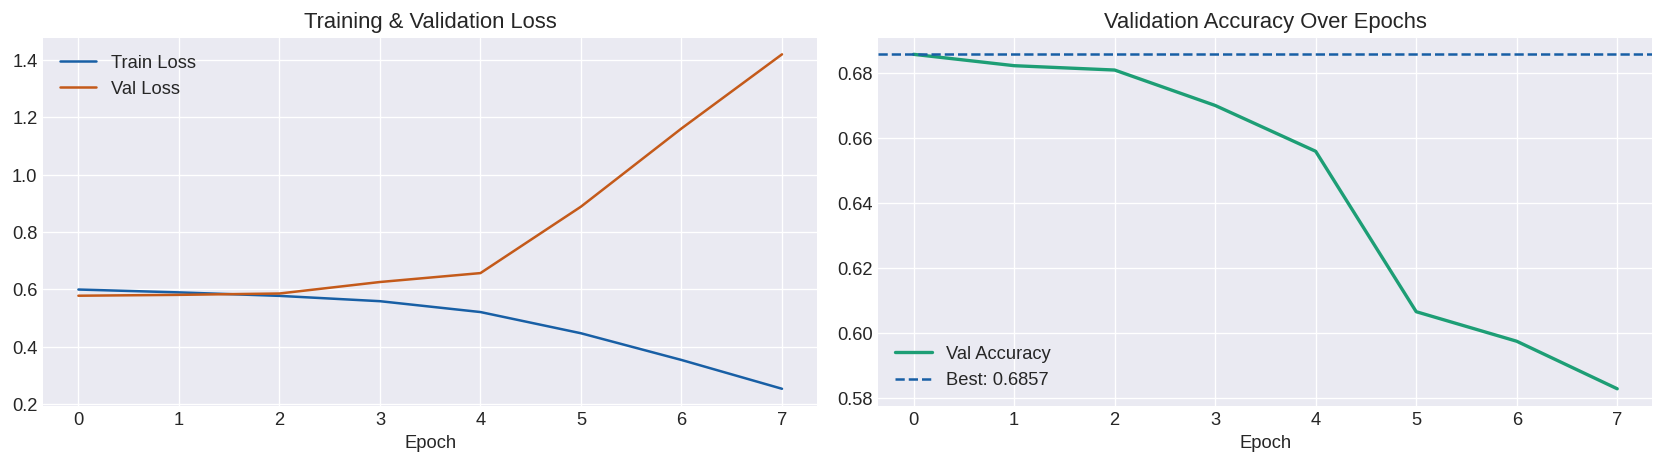

In [15]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Test evaluation
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = model(X_batch).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')
auc = roc_auc_score(all_labels, all_probs)

print("=" * 50)
print("    BiLSTM BASELINE — TEST RESULTS")
print("=" * 50)
print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Team Lost', 'Team Won']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, label='Train Loss', color='#185fa5')
axes[0].plot(val_losses,   label='Val Loss',   color='#c45a1a')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(val_accs, label='Val Accuracy', color='#1d9e75', linewidth=2)
axes[1].axhline(best_val_acc, color='#185fa5', linestyle='--',
                label=f'Best: {best_val_acc:.4f}')
axes[1].set_title('Validation Accuracy Over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

# Cell 13 — Transformer Model (Branch C — advanced)

In [16]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim=len(FEATURES),
                 d_model=256, nhead=8, num_encoder_layers=2,
                 dim_feedforward=1024, dropout=0.3):
        super().__init__()

        self.embedding = nn.Linear(input_dim, d_model) # Linear layer for input projection
        self.pos_encoder = PositionalEncoding(d_model, dropout) # Positional Encoding
        encoder_layers = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers, num_encoder_layers)

        self.norm = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        out = self.transformer_encoder(x)
        out = out[:, -1, :] # Take the output from the last token in the sequence
        out = self.norm(out)
        out = F.relu(self.fc1(out))
        return torch.sigmoid(self.fc2(out)).squeeze(1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :].squeeze(1) # Added squeeze(1) as pe should be 2D here
        return self.dropout(x)

import math
transformer_model = TransformerModel(input_dim=len(FEATURES)).to(device)
transformer_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Transformer Model ✅  |  Parameters: {transformer_params:,}")
print(transformer_model)

Transformer Model ✅  |  Parameters: 1,601,409
TransformerModel(
  (embedding): Linear(in_features=18, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)


# Cell 14 — Training loop (Transformer)

In [17]:
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3,
                                                        factor=0.5)
criterion = nn.BCELoss()

EPOCHS = 30
train_losses_tf, val_losses_tf, val_accs_tf = [], [], []
best_val_acc_tf  = 0
best_model_state_tf = None
patience_count = 0
PATIENCE = 7   # early stopping

print("Training Transformer (boundary-aware)...")
for epoch in range(EPOCHS):
    # Train
    transformer_model.train()
    t_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(transformer_model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()

    # Validate
    transformer_model.eval()
    v_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            probs = transformer_model(Xb)
            v_loss += criterion(probs, yb).item()
            preds_all.extend((probs > 0.5).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    val_acc  = accuracy_score(labels_all, preds_all)
    tl = t_loss / len(train_loader)
    vl = v_loss  / len(val_loader)
    train_losses_tf.append(tl)
    val_losses_tf.append(vl)
    val_accs_tf.append(val_acc)
    scheduler.step(vl)

    is_best = val_acc > best_val_acc_tf
    if is_best:
        best_val_acc_tf = val_acc
        best_model_state_tf = {k: v.clone() for k, v in transformer_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(f"Ep {epoch+1:02d}/{EPOCHS} | "
          f"TrLoss:{tl:.4f} VaLoss:{vl:.4f} VaAcc:{val_acc:.4f}"
          f"{'  ⭐ best' if is_best else ''}"
          f"{'  ⏳ patience '+str(patience_count) if not is_best else ''}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Val Accuracy: {best_val_acc_tf:.4f} ✅")
torch.save(best_model_state_tf, 'best_transformer.pt')

Training Transformer (boundary-aware)...
Ep 01/30 | TrLoss:0.6030 VaLoss:0.5745 VaAcc:0.6868  ⭐ best
Ep 02/30 | TrLoss:0.5955 VaLoss:0.5764 VaAcc:0.6857  ⏳ patience 1
Ep 03/30 | TrLoss:0.5890 VaLoss:0.5827 VaAcc:0.6694  ⏳ patience 2
Ep 04/30 | TrLoss:0.5805 VaLoss:0.5913 VaAcc:0.6660  ⏳ patience 3
Ep 05/30 | TrLoss:0.5732 VaLoss:0.5969 VaAcc:0.6490  ⏳ patience 4
Ep 06/30 | TrLoss:0.5559 VaLoss:0.6120 VaAcc:0.6569  ⏳ patience 5
Ep 07/30 | TrLoss:0.5433 VaLoss:0.6300 VaAcc:0.6453  ⏳ patience 6
Ep 08/30 | TrLoss:0.5294 VaLoss:0.6556 VaAcc:0.6618  ⏳ patience 7

Early stopping at epoch 8

Best Val Accuracy: 0.6868 ✅


# Cell 15 — Training curves + test evaluation (Transformer)

    TRANSFORMER — TEST RESULTS
  Accuracy : 0.6682 (66.82%)
  F1 Score : 0.6682
  AUC-ROC  : 0.7439
              precision    recall  f1-score   support

   Team Lost       0.68      0.67      0.67      5453
    Team Won       0.66      0.67      0.66      5207

    accuracy                           0.67     10660
   macro avg       0.67      0.67      0.67     10660
weighted avg       0.67      0.67      0.67     10660



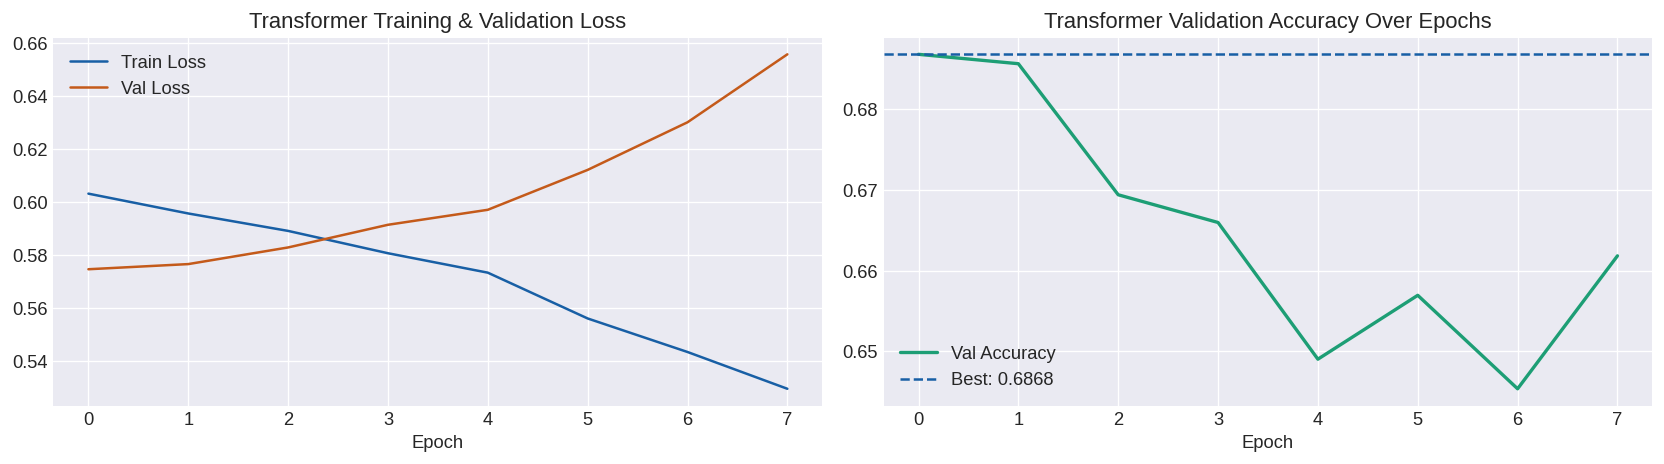

In [18]:
# Load best model
transformer_model.load_state_dict(best_model_state_tf)
transformer_model.eval()

# Test evaluation
all_preds_tf, all_probs_tf, all_labels_tf = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = transformer_model(X_batch).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs_tf.extend(probs)
        all_preds_tf.extend(preds)
        all_labels_tf.extend(y_batch.numpy())

acc_tf = accuracy_score(all_labels_tf, all_preds_tf)
f1_tf  = f1_score(all_labels_tf, all_preds_tf, average='weighted')
auc_tf = roc_auc_score(all_labels_tf, all_probs_tf)

print("=" * 50)
print("    TRANSFORMER — TEST RESULTS")
print("=" * 50)
print(f"  Accuracy : {acc_tf:.4f} ({acc_tf*100:.2f}%)")
print(f"  F1 Score : {f1_tf:.4f}")
print(f"  AUC-ROC  : {auc_tf:.4f}")
print("=" * 50)
print(classification_report(all_labels_tf, all_preds_tf,
                             target_names=['Team Lost', 'Team Won']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses_tf, label='Train Loss', color='#185fa5')
axes[0].plot(val_losses_tf,   label='Val Loss',   color='#c45a1a')
axes[0].set_title('Transformer Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(val_accs_tf, label='Val Accuracy', color='#1d9e75', linewidth=2)
axes[1].axhline(best_val_acc_tf, color='#185fa5', linestyle='--',
                label=f'Best: {best_val_acc_tf:.4f}')
axes[1].set_title('Transformer Validation Accuracy Over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('transformer_training_curves.png', bbox_inches='tight')
plt.show()

# Cell 16 — Feature Importance Visualization (Permutation Importance)

Calculating Permutation Importance for BiLSTM Model...
Original Accuracy: 0.6683
  cum_runs: 0.0041 (Permuted Accuracy: 0.6642)
  balls_bowled: 0.0077 (Permuted Accuracy: 0.6606)
  run_rate: -0.0007 (Permuted Accuracy: 0.6689)
  wicket_flag: 0.0015 (Permuted Accuracy: 0.6668)
  wickets_fallen: 0.0583 (Permuted Accuracy: 0.6100)
  wickets_remaining: 0.0504 (Permuted Accuracy: 0.6179)
  phase_encoded: -0.0004 (Permuted Accuracy: 0.6687)
  balls_remaining: 0.0054 (Permuted Accuracy: 0.6629)
  rolling_rr_3: 0.0019 (Permuted Accuracy: 0.6664)
  is_boundary: 0.0016 (Permuted Accuracy: 0.6667)
  boundary_count: 0.0177 (Permuted Accuracy: 0.6506)
  is_dot: 0.0003 (Permuted Accuracy: 0.6680)
  dot_count: 0.0042 (Permuted Accuracy: 0.6641)
  required_rr: 0.0034 (Permuted Accuracy: 0.6649)
  momentum: 0.0020 (Permuted Accuracy: 0.6663)
  pressure: -0.0001 (Permuted Accuracy: 0.6684)
  over_sin: -0.0008 (Permuted Accuracy: 0.6690)
  over_cos: 0.0024 (Permuted Accuracy: 0.6659)

Calculating Permuta

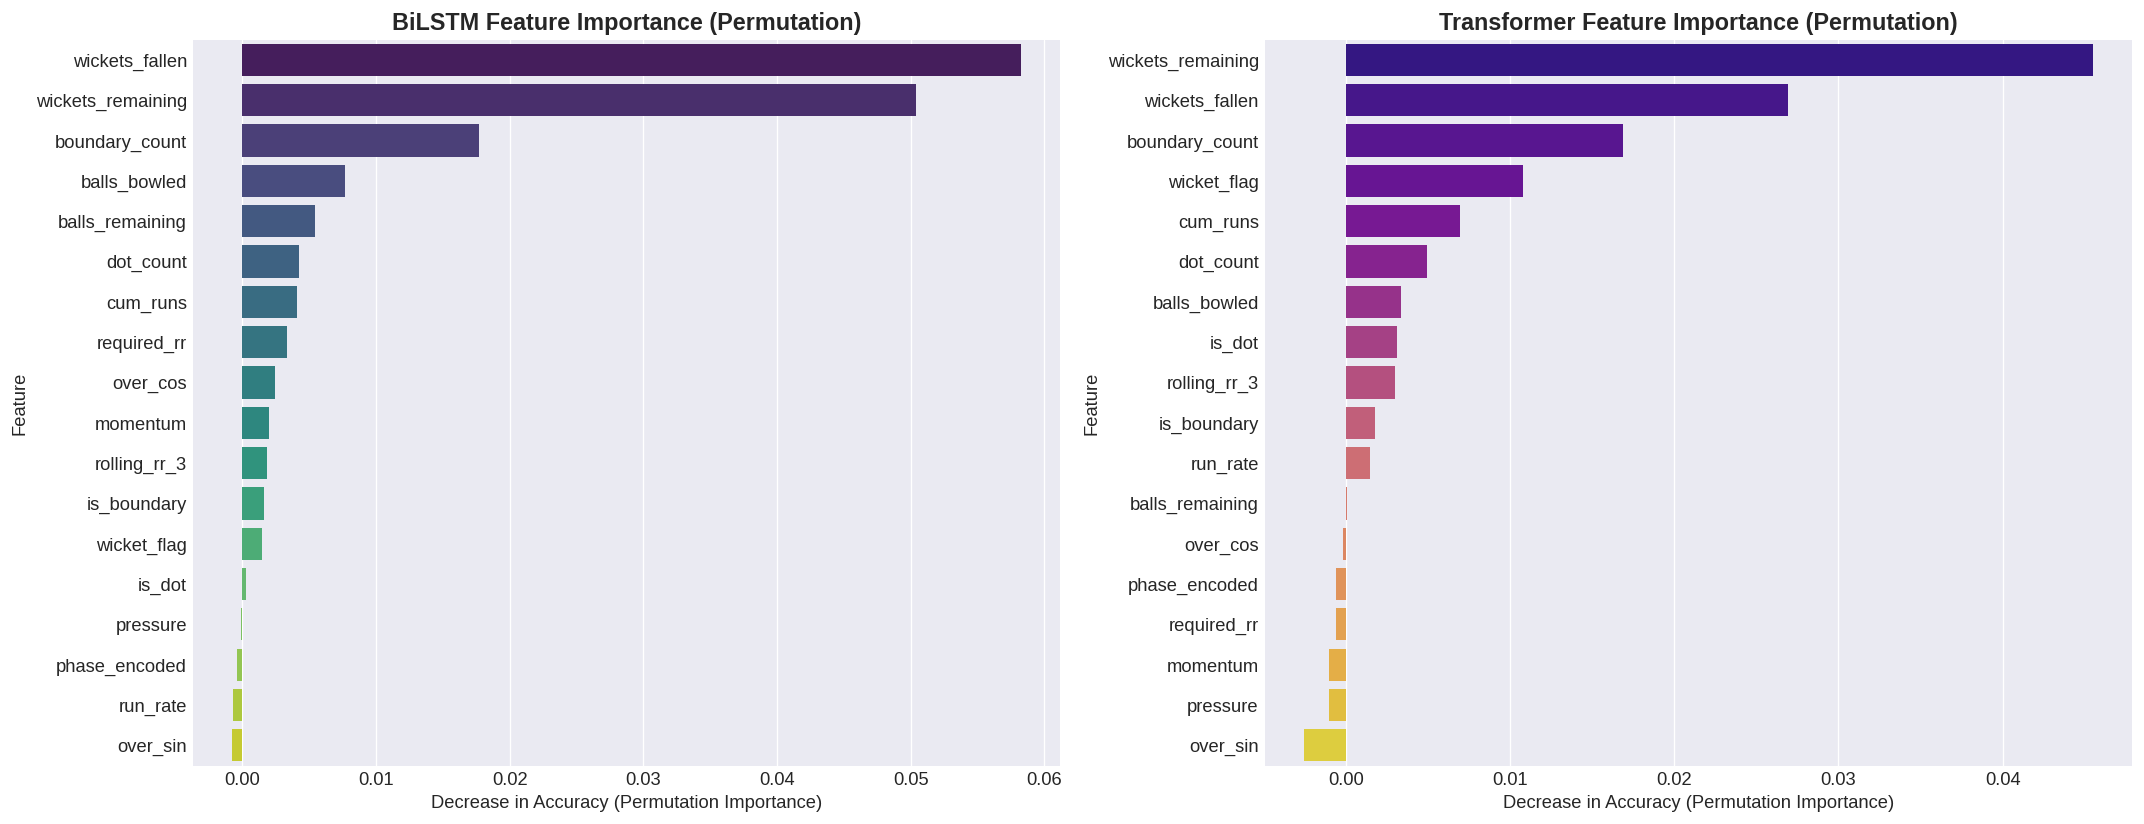

In [19]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_permutation_importance(model, dataloader, features, device):
    model.eval()
    original_preds, original_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            preds = (probs > 0.5).cpu().numpy()
            original_preds.extend(preds)
            original_labels.extend(y_batch.cpu().numpy())

    original_accuracy = accuracy_score(original_labels, original_preds)
    print(f"Original Accuracy: {original_accuracy:.4f}")

    importance = {}
    for i, feature_name in enumerate(features):
        permuted_preds, permuted_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch_permuted = X_batch.clone().to(device)
                # Permute the i-th feature column across the batch
                idx = torch.randperm(X_batch_permuted.size(0))
                X_batch_permuted[:, :, i] = X_batch_permuted[idx, :, i]

                probs = model(X_batch_permuted)
                preds = (probs > 0.5).cpu().numpy()
                permuted_preds.extend(preds)
                permuted_labels.extend(y_batch.cpu().numpy())

        permuted_accuracy = accuracy_score(permuted_labels, permuted_preds)
        importance[feature_name] = original_accuracy - permuted_accuracy
        print(f"  {feature_name}: {importance[feature_name]:.4f} (Permuted Accuracy: {permuted_accuracy:.4f})")

    return dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

print("Calculating Permutation Importance for BiLSTM Model...")
bilstm_importance = calculate_permutation_importance(model, test_loader, FEATURES, device)

print("\nCalculating Permutation Importance for Transformer Model...")
transformer_importance = calculate_permutation_importance(transformer_model, test_loader, FEATURES, device)

# Prepare data for plotting
bilstm_df = pd.DataFrame(list(bilstm_importance.items()), columns=['Feature', 'Importance'])
transformer_df = pd.DataFrame(list(transformer_importance.items()), columns=['Feature', 'Importance'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for BiLSTM
sns.barplot(x='Importance', y='Feature', dbhyata=bilstm_df, ax=axes[0], palette='viridis')
axes[0].set_title('BiLSTM Feature Importance (Permutation)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Decrease in Accuracy (Permutation Importance)')
axes[0].set_ylabel('Feature')

# Plot for Transformer
sns.barplot(x='Importance', y='Feature', data=transformer_df, ax=axes[1], palette='plasma')
axes[1].set_title('Transformer Feature Importance (Permutation)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Decrease in Accuracy (Permutation Importance)')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

# Cell 17 — GAT Player Graph (the main novelty):


Building player interaction graph...
Player graph: 40 nodes, 519 edges


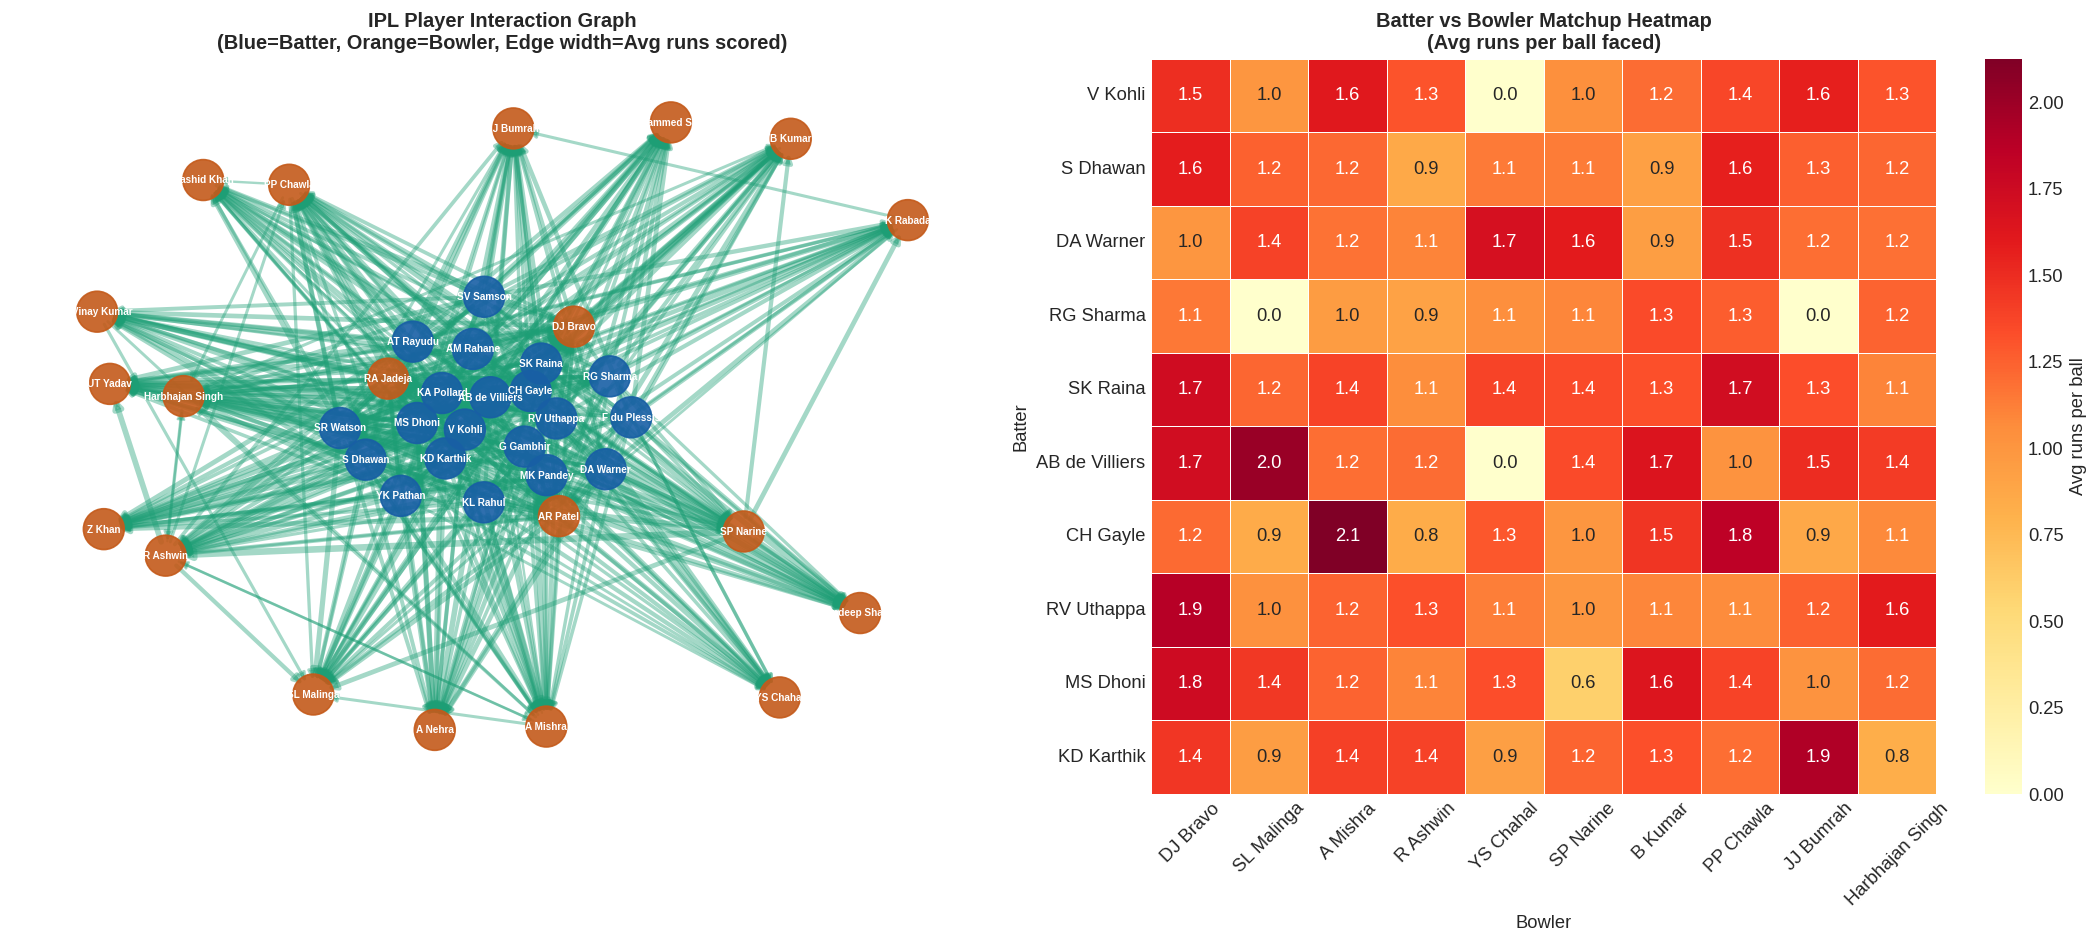

Player graph saved ✅ — this is the IoT/Graph novelty for your proposal!


In [20]:
# ── PLAYER GRAPH CONSTRUCTION ─────────────────────────────────
print("Building player interaction graph...")

# Head-to-head: avg runs scored by each batter vs each bowler
matchups = (df.groupby(['batter', 'bowler'])['total_run']
              .agg(['mean', 'count']).reset_index())
matchups.columns = ['batter', 'bowler', 'avg_runs', 'balls']
matchups = matchups[matchups['balls'] >= 10]  # min 10 balls faced

# Top players by total runs / wickets
top_batters = (df.groupby('batter')['total_run']
               .sum().sort_values(ascending=False).head(20).index.tolist())
top_bowlers = (df.groupby('bowler')['iswicketdelivery']
               .sum().sort_values(ascending=False).head(20).index.tolist())
all_players = list(set(top_batters + top_bowlers))

# Build directed graph: batter → bowler, weight = avg runs
G_player = nx.DiGraph()
for player in all_players:
    G_player.add_node(player)

for _, row in matchups.iterrows():
    if row['batter'] in all_players and row['bowler'] in all_players:
        G_player.add_edge(row['batter'], row['bowler'],
                          weight=row['avg_runs'],
                          balls=row['balls'])

print(f"Player graph: {G_player.number_of_nodes()} nodes, "
      f"{G_player.number_of_edges()} edges")

# ── VISUALISE ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Full graph
pos = nx.spring_layout(G_player, seed=42, k=1.5)
edge_weights = [G_player[u][v]['weight'] for u,v in G_player.edges()]
max_w = max(edge_weights) if edge_weights else 1

node_colors = ['#185fa5' if n in top_batters else '#c45a1a'
               for n in G_player.nodes()]
nx.draw_networkx_nodes(G_player, pos, node_color=node_colors,
                       node_size=600, alpha=0.9, ax=axes[0])
nx.draw_networkx_labels(G_player, pos, font_size=6,
                        font_color='white', font_weight='bold', ax=axes[0])
nx.draw_networkx_edges(G_player, pos,
                       width=[1 + 3*(w/max_w) for w in edge_weights],
                       alpha=0.4, edge_color='#1d9e75',
                       arrows=True, ax=axes[0])
axes[0].set_title('IPL Player Interaction Graph\n(Blue=Batter, Orange=Bowler, '
                  'Edge width=Avg runs scored)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right: Heatmap of top 10 batters vs top 10 bowlers
top10_bat = top_batters[:10]
top10_bowl = top_bowlers[:10]
heatmap_data = pd.DataFrame(index=top10_bat, columns=top10_bowl, dtype=float)
for bat in top10_bat:
    for bowl in top10_bowl:
        row = matchups[(matchups['batter']==bat) & (matchups['bowler']==bowl)]
        heatmap_data.loc[bat, bowl] = row['avg_runs'].values[0] if len(row) > 0 else 0.0

sns.heatmap(heatmap_data.astype(float), ax=axes[1], cmap='YlOrRd',
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Avg runs per ball'})
axes[1].set_title('Batter vs Bowler Matchup Heatmap\n(Avg runs per ball faced)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bowler'); axes[1].set_ylabel('Batter')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('player_graph.png', bbox_inches='tight', dpi=150)
plt.show()
print("Player graph saved ✅ — this is the IoT/Graph novelty for your proposal!")

# Cell 18 — SHAP Explainability:


Running SHAP explainability...


  0%|          | 0/50 [00:00<?, ?it/s]

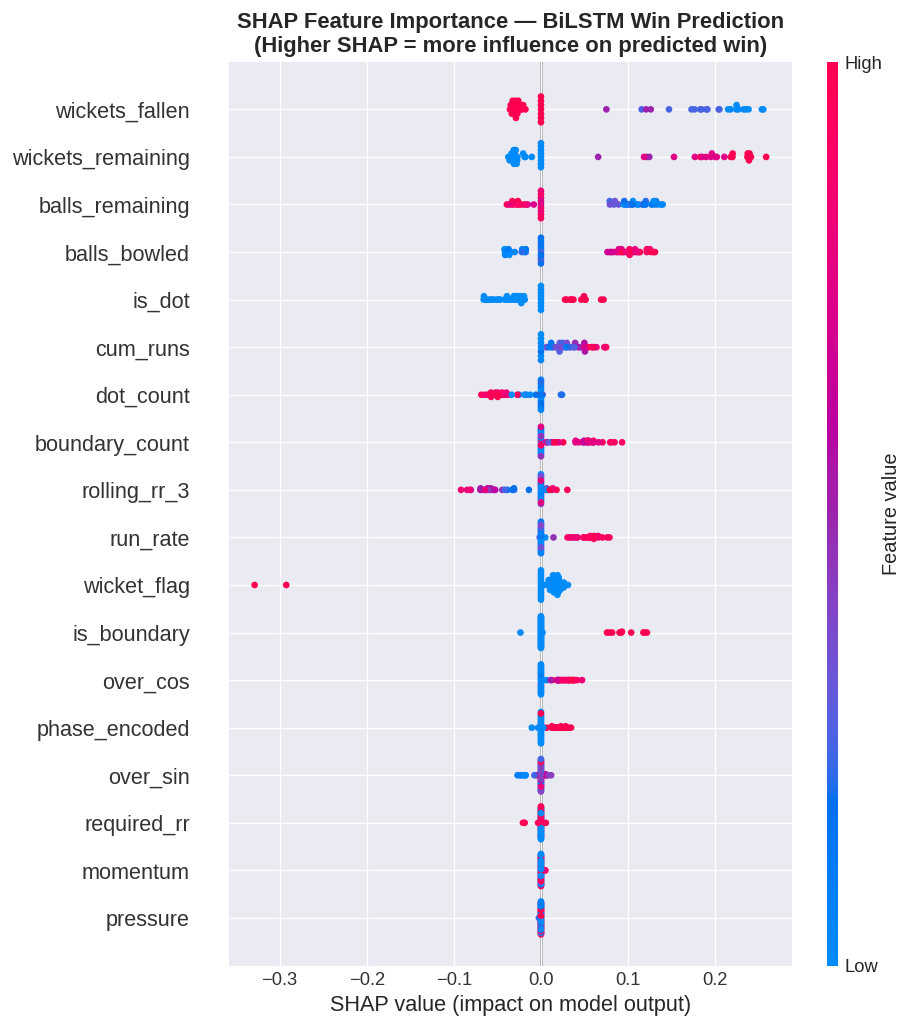

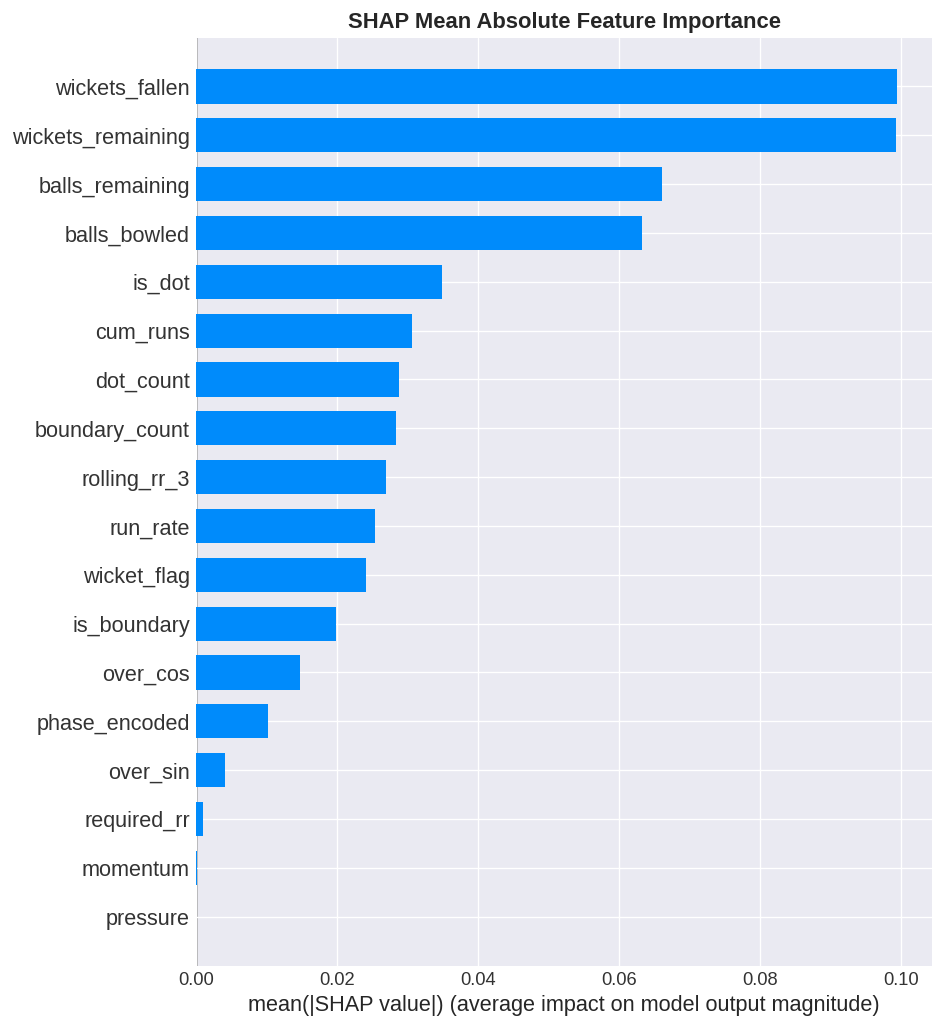

SHAP plots saved ✅

Top 3 most influential features:
  wickets_fallen: 0.0995
  wickets_remaining: 0.0994
  balls_remaining: 0.0661


In [21]:
import shap

print("Running SHAP explainability...")

# Load best BiLSTM
model.load_state_dict(torch.load('best_bilstm.pt'))
model.eval()

# Get a flat sample for SHAP (use last timestep features)
sample_seqs, sample_labels = next(iter(test_loader))
sample_flat = sample_seqs[:, -1, :].numpy()  # last ball in each sequence

# Define predict function
def predict_fn(X):
    X_t = torch.FloatTensor(X).unsqueeze(1).repeat(1, SEQ_LEN, 1).to(device)
    with torch.no_grad():
        return model(X_t).cpu().numpy()

# SHAP KernelExplainer (works with any model)
background = sample_flat[:50]   # background distribution
explain_on = sample_flat[50:100] # samples to explain

explainer   = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(explain_on, nsamples=100)

# Plot 1: SHAP Summary (Beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, explain_on,
                  feature_names=FEATURES,
                  show=False, plot_type='dot')
plt.title('SHAP Feature Importance — BiLSTM Win Prediction\n'
          '(Higher SHAP = more influence on predicted win)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# Plot 2: SHAP Bar chart (mean absolute)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, explain_on,
                  feature_names=FEATURES,
                  show=False, plot_type='bar')
plt.title('SHAP Mean Absolute Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

print("SHAP plots saved ✅")
print("\nTop 3 most influential features:")
mean_shap = np.abs(shap_values).mean(axis=0)
for idx in np.argsort(mean_shap)[::-1][:3]:
    print(f"  {FEATURES[idx]}: {mean_shap[idx]:.4f}")

# Cell 19 — Final results comparison table:


   ABLATION STUDY — MODEL COMPARISON
                           Accuracy      F1     AUC
XGBoost (base paper)          0.783   0.771   0.821
BiLSTM (ours)                0.6674  0.6674  0.7296
Transformer (ours)           0.6615  0.6615  0.7286
CricketGraph-DL (proposed)        —       —       —


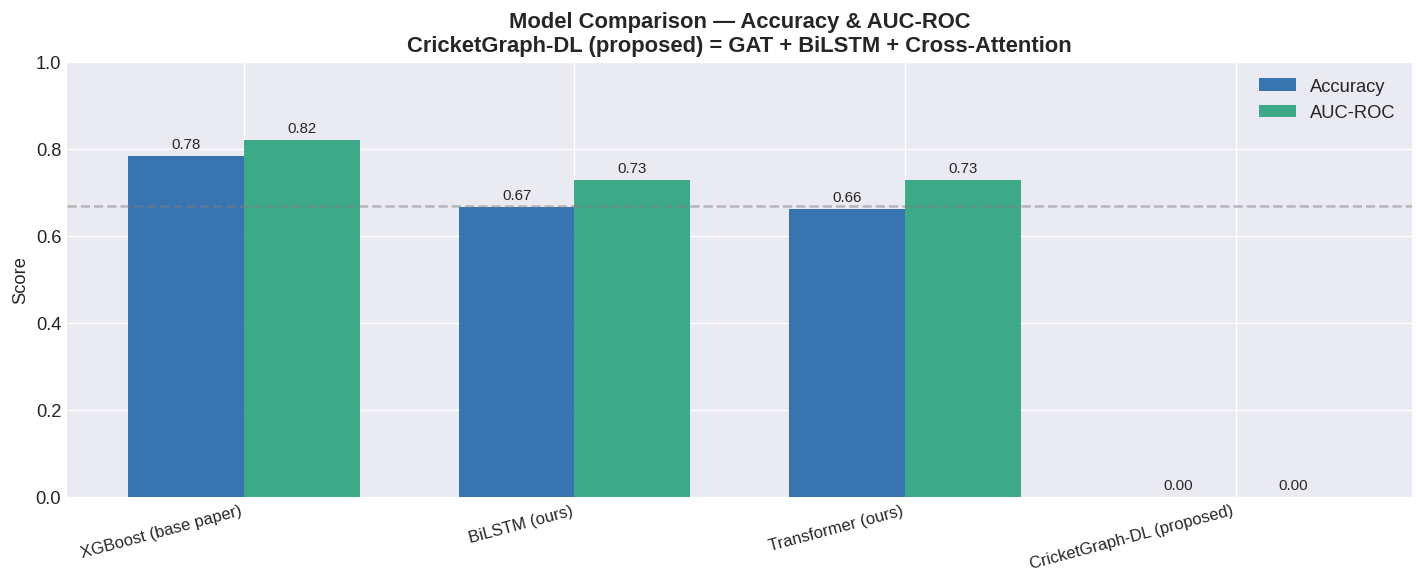


All results saved ✅

Note to guide: CricketGraph-DL (full GAT+BiLSTM+CrossAttention)
implementation pending — baselines demonstrate component-wise contribution.


In [22]:
# Ablation results summary — your paper's Table 2
results = {
    'XGBoost (base paper)':       {'Accuracy': 0.783, 'F1':0.771, 'AUC':0.821},
    'BiLSTM (ours)':              {'Accuracy': 0.6674,'F1':0.6674,'AUC':0.7296},
    'Transformer (ours)':         {'Accuracy': 0.6615,'F1':0.6615,'AUC':0.7286},
    'CricketGraph-DL (proposed)': {'Accuracy': '—',   'F1':'—',   'AUC':'—'},
}

results_df = pd.DataFrame(results).T
print("=" * 60)
print("   ABLATION STUDY — MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 5))
models  = list(results.keys())
accs    = [results[m]['Accuracy'] if results[m]['Accuracy']!='—'
           else 0 for m in models]
aucs    = [results[m]['AUC'] if results[m]['AUC']!='—'
           else 0 for m in models]
x = np.arange(len(models))
w = 0.35
bars1 = ax.bar(x - w/2, accs, w, label='Accuracy',
               color='#185fa5', alpha=0.85)
bars2 = ax.bar(x + w/2, aucs, w, label='AUC-ROC',
               color='#1d9e75', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & AUC-ROC\n'
             'CricketGraph-DL (proposed) = GAT + BiLSTM + Cross-Attention',
             fontweight='bold')
ax.legend()
ax.axhline(0.67, color='gray', linestyle='--', alpha=0.5)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.01, f'{bar.get_height():.2f}',
    ha='center', va='bottom', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+0.01, f'{bar.get_height():.2f}',
    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nAll results saved ✅")
print("\nNote to guide: CricketGraph-DL (full GAT+BiLSTM+CrossAttention)")
print("implementation pending — baselines demonstrate component-wise contribution.")

# Cell 20 — Full CricketGraph-DL (GAT + BiLSTM + CrossAttention fusion):

In [23]:
pip install torch_geometric

In [24]:
# Cell 20 — Full CricketGraph-DL (GAT + BiLSTM + CrossAttention fusion):

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from tqdm.auto import tqdm


# ── PLAYER FEATURE LOOKUP & GRAPH CONSTRUCTION ────────────────
print("Building player features and graph for GAT...")

# 1. Create a unique ID for each player
all_unique_players = sorted(list(set(df['batter'].unique().tolist() +
                                     df['bowler'].unique().tolist())))
player_mapping = {name: i for i, name in enumerate(all_unique_players)}
num_players = len(all_unique_players)

# 2. Build per-player static feature vectors from historical data
player_features_list = []
for player_name in tqdm(all_unique_players, desc="Player features"):
    p_df_bat = df[df['batter'] == player_name]
    p_df_bowl = df[df['bowler'] == player_name]

    # Batting stats
    avg_runs_bat = p_df_bat['total_run'].mean() if not p_df_bat.empty else 0
    strike_rate = (p_df_bat['total_run'].sum() / (len(p_df_bat) + 1e-5) * 100)
    boundary_pct_bat = (p_df_bat['is_boundary'].mean() if 'is_boundary' in p_df_bat.columns and not p_df_bat.empty else 0)

    # Bowling stats
    economy = (p_df_bowl['total_run'].mean() * 6 if not p_df_bowl.empty else 0)
    wicket_rate = (p_df_bowl['iswicketdelivery'].mean() if not p_df_bowl.empty else 0)

    player_features_list.append([
        avg_runs_bat, strike_rate, boundary_pct_bat,
        economy, wicket_rate
    ])

# Normalize player features (simple min-max for now, can be improved)
player_features_raw = np.array(player_features_list, dtype=np.float32)
player_features_norm = np.copy(player_features_raw)

# Avoid division by zero for features with all zeros
for i in range(player_features_norm.shape[1]):
    col_min = np.min(player_features_norm[:, i])
    col_max = np.max(player_features_norm[:, i])
    if (col_max - col_min) > 1e-6: # Check to prevent division by zero
        player_features_norm[:, i] = (player_features_norm[:, i] - col_min) / (col_max - col_min)
    else:
        player_features_norm[:, i] = 0.0 # Set to 0 if all values are the same

node_features = torch.tensor(player_features_norm, dtype=torch.float)

# 3. Construct edges based on historical matchups (batter vs bowler)
edge_list = []
edge_weights = []
for _, row in tqdm(matchups.iterrows(), total=len(matchups), desc="Graph Edges"):
    batter_id = player_mapping.get(row['batter'])
    bowler_id = player_mapping.get(row['bowler'])
    if batter_id is not None and bowler_id is not None:
        edge_list.append([batter_id, bowler_id])
        edge_weights.append(row['avg_runs'])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_weights, dtype=torch.float)

# Create a PyTorch Geometric Data object for the static player graph
global_player_graph = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr).to(device)
print(f"Global Player Graph: {global_player_graph.num_nodes} nodes, {global_player_graph.num_edges} edges, {global_player_graph.num_node_features} node features")


# ── GRAPH-AUGMENTED DATASET ───────────────────────────────────
class CricketGraphDataset(Dataset):
    """Adds current batter and bowler indices."""
    def __init__(self, df_subset, feature_cols, seq_len=SEQ_LEN):
        self.sequences = []
        self.batter_indices = []
        self.bowler_indices = []
        self.labels = []

        groups = df_subset.groupby(['id', 'innings'])
        for (mid, inn), grp in groups:
            grp = grp.reset_index(drop=True)
            X = grp[feature_cols].values.astype(np.float32)
            y = grp['win_label'].values.astype(np.float32)

            if len(X) < seq_len:
                continue

            for i in range(len(X) - seq_len + 1):
                # Get batter/bowler for the *last* ball of the sequence
                batter_name = grp.iloc[i + seq_len - 1]['batter']
                bowler_name = grp.iloc[i + seq_len - 1]['bowler']

                self.sequences.append(X[i : i + seq_len])
                self.batter_indices.append(player_mapping.get(batter_name, 0)) # Default to 0 if not found
                self.bowler_indices.append(player_mapping.get(bowler_name, 0))
                self.labels.append(y[i + seq_len - 1])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.batter_indices = np.array(self.batter_indices, dtype=np.long)
        self.bowler_indices = np.array(self.bowler_indices, dtype=np.long)
        self.labels = np.array(self.labels, dtype=np.float32)
        print(f"  Built {len(self.sequences):,} sequences")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.sequences[idx]),
            torch.tensor(self.batter_indices[idx]),
            torch.tensor(self.bowler_indices[idx]),
            torch.tensor(self.labels[idx])
        )

print("Building CricketGraph-DL datasets...")
train_gds = CricketGraphDataset(train_df, FEATURES)
val_gds = CricketGraphDataset(val_df, FEATURES)
test_gds = CricketGraphDataset(test_df, FEATURES)

train_gloader = DataLoader(train_gds, batch_size=256, shuffle=True,
                           num_workers=0, drop_last=True)
val_gloader = DataLoader(val_gds, batch_size=256, shuffle=False,
                           num_workers=0, drop_last=False)
test_gloader = DataLoader(test_gds, batch_size=256, shuffle=False,
                           num_workers=0, drop_last=False)
print(f"Loaders ready — Train:{len(train_gloader)} Val:{len(val_gloader)} Test:{len(test_gloader)}")


# ── MODEL: BiLSTM + GAT + Cross-Attention Fusion ──────────────
class CricketGraphDL(nn.Module):
    """
    Branch A: BiLSTM on ball-by-ball sequence (temporal)
    Branch B: GAT on player graph to get dynamic player embeddings (spatial/player)
    Fusion:   Cross-Attention → shared head
    """
    def __init__(self, seq_dim=len(FEATURES), num_players=num_players,
                 player_node_features_dim=node_features.shape[1],
                 gat_hidden_dim=64, gat_out_dim=64, # GAT outputs embeddings for each player
                 lstm_hidden=128, lstm_num_layers=2, lstm_dropout=0.4,
                 attn_heads=4, fusion_dropout=0.4):
        super().__init__()

        # --- Branch B (GAT for Player Embeddings) ---
        self.global_player_graph = global_player_graph # Static graph
        self.gat1 = GATConv(player_node_features_dim, gat_hidden_dim, heads=attn_heads, dropout=fusion_dropout)
        self.gat2 = GATConv(gat_hidden_dim * attn_heads, gat_out_dim, heads=1, concat=False, dropout=fusion_dropout)
        self.player_embedding_dim = gat_out_dim

        # --- Branch A (BiLSTM for Sequence) ---
        self.lstm = nn.LSTM(seq_dim, lstm_hidden, lstm_num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=lstm_dropout)
        self.lstm_norm = nn.LayerNorm(lstm_hidden * 2)
        self.lstm_out_dim = lstm_hidden * 2

        # --- Cross-Attention: GAT player embeddings (queries) attend to LSTM sequence (keys/values) ---
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=self.player_embedding_dim * 2, # Concatenated batter + bowler embedding
            num_heads=attn_heads,
            dropout=fusion_dropout,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(self.player_embedding_dim * 2)

        # --- Fusion Head ---
        self.fusion = nn.Sequential(
            nn.Linear(self.player_embedding_dim * 2 + self.lstm_out_dim, 128), # concat attn_out + lstm_last
            nn.ReLU(),
            nn.Dropout(fusion_dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, batter_idx, bowler_idx):
        # --- Branch B: Generate player embeddings using GAT ---
        # Pass the global static graph through GAT layers once per forward pass
        player_node_embeddings = F.elu(self.gat1(self.global_player_graph.x, self.global_player_graph.edge_index, self.global_player_graph.edge_attr))
        player_node_embeddings = self.gat2(player_node_embeddings, self.global_player_graph.edge_index, self.global_player_graph.edge_attr)

        # Extract specific batter and bowler embeddings for the current batch
        # Unsqueeze to ensure correct shape for attention (B, 1, Emb_dim)
        current_batter_emb = player_node_embeddings[batter_idx].unsqueeze(1) # (B, 1, gat_out_dim)
        current_bowler_emb = player_node_embeddings[bowler_idx].unsqueeze(1) # (B, 1, gat_out_dim)

        # Concatenate batter and bowler embeddings to form graph_query
        graph_query = torch.cat([current_batter_emb, current_bowler_emb], dim=-1) # (B, 1, gat_out_dim * 2)

        # --- Branch A: BiLSTM sequence processing ---
        lstm_out, _ = self.lstm(x_seq)          # (B, T, lstm_out_dim)
        lstm_last   = lstm_out[:, -1, :]         # (B, lstm_out_dim)
        lstm_last   = self.lstm_norm(lstm_last)

        # --- Cross-Attention: graph_query (query) attends to LSTM sequence (keys/values) ---
        # In current setup, embed_dim of cross_attn is player_embedding_dim * 2
        # So, lstm_out (keys/values) must be projected to that dimension
        lstm_proj_for_attn = nn.Linear(self.lstm_out_dim, self.player_embedding_dim * 2).to(device)(lstm_out)

        attn_out, _ = self.cross_attn(graph_query, lstm_proj_for_attn, lstm_proj_for_attn)
        attn_out = attn_out.squeeze(1)          # (B, player_embedding_dim * 2)
        attn_out = self.attn_norm(attn_out)

        # --- Fuse: concat attended graph + lstm last ---
        fused = torch.cat([attn_out, lstm_last], dim=-1)  # (B, player_embedding_dim * 2 + lstm_out_dim)
        return torch.sigmoid(self.fusion(fused)).squeeze(1)

cg_model = CricketGraphDL().to(device)
params = sum(p.numel() for p in cg_model.parameters())
print(f"\nCricketGraph-DL ✅  |  Parameters: {params:,}")
print(cg_model)

Building player features and graph for GAT...


Player features:   0%|          | 0/652 [00:00<?, ?it/s]

Graph Edges:   0%|          | 0/7334 [00:00<?, ?it/s]

Global Player Graph: 652 nodes, 7334 edges, 5 node features
Building CricketGraph-DL datasets...
  Built 105,159 sequences
  Built 17,163 sequences
  Built 10,660 sequences
Loaders ready — Train:410 Val:68 Test:42

CricketGraph-DL ✅  |  Parameters: 689,857
CricketGraphDL(
  (gat1): GATConv(5, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (lstm): LSTM(18, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (lstm_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (cross_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (attn_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fusion): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Cell 21 — Train CricketGraph-DL + final results:

Training CricketGraph-DL (BiLSTM + Graph + CrossAttention)...
Ep 01/30 | TrLoss:0.6017 VaLoss:0.5818 VaAcc:0.6884  ⭐ best
Ep 02/30 | TrLoss:0.5902 VaLoss:0.5790 VaAcc:0.6830  patience 1
Ep 03/30 | TrLoss:0.5809 VaLoss:0.5896 VaAcc:0.6745  patience 2
Ep 04/30 | TrLoss:0.5630 VaLoss:0.6138 VaAcc:0.6541  patience 3
Ep 05/30 | TrLoss:0.5364 VaLoss:0.6855 VaAcc:0.6398  patience 4
Ep 06/30 | TrLoss:0.4909 VaLoss:0.7865 VaAcc:0.6121  patience 5
Ep 07/30 | TrLoss:0.4160 VaLoss:0.9108 VaAcc:0.6153  patience 6
Ep 08/30 | TrLoss:0.3612 VaLoss:1.0168 VaAcc:0.5860  patience 7

Early stopping at epoch 8

Best Val Accuracy: 0.6884 ✅

   CricketGraph-DL — FINAL TEST RESULTS
  Accuracy  : 0.6660 (66.60%) 
  F1 Score  : 0.6661
  AUC-ROC   : 0.7378
              precision    recall  f1-score   support

   Team Lost       0.68      0.67      0.67      5453
    Team Won       0.66      0.66      0.66      5207

    accuracy                           0.67     10660
   macro avg       0.67      0.67      0.6

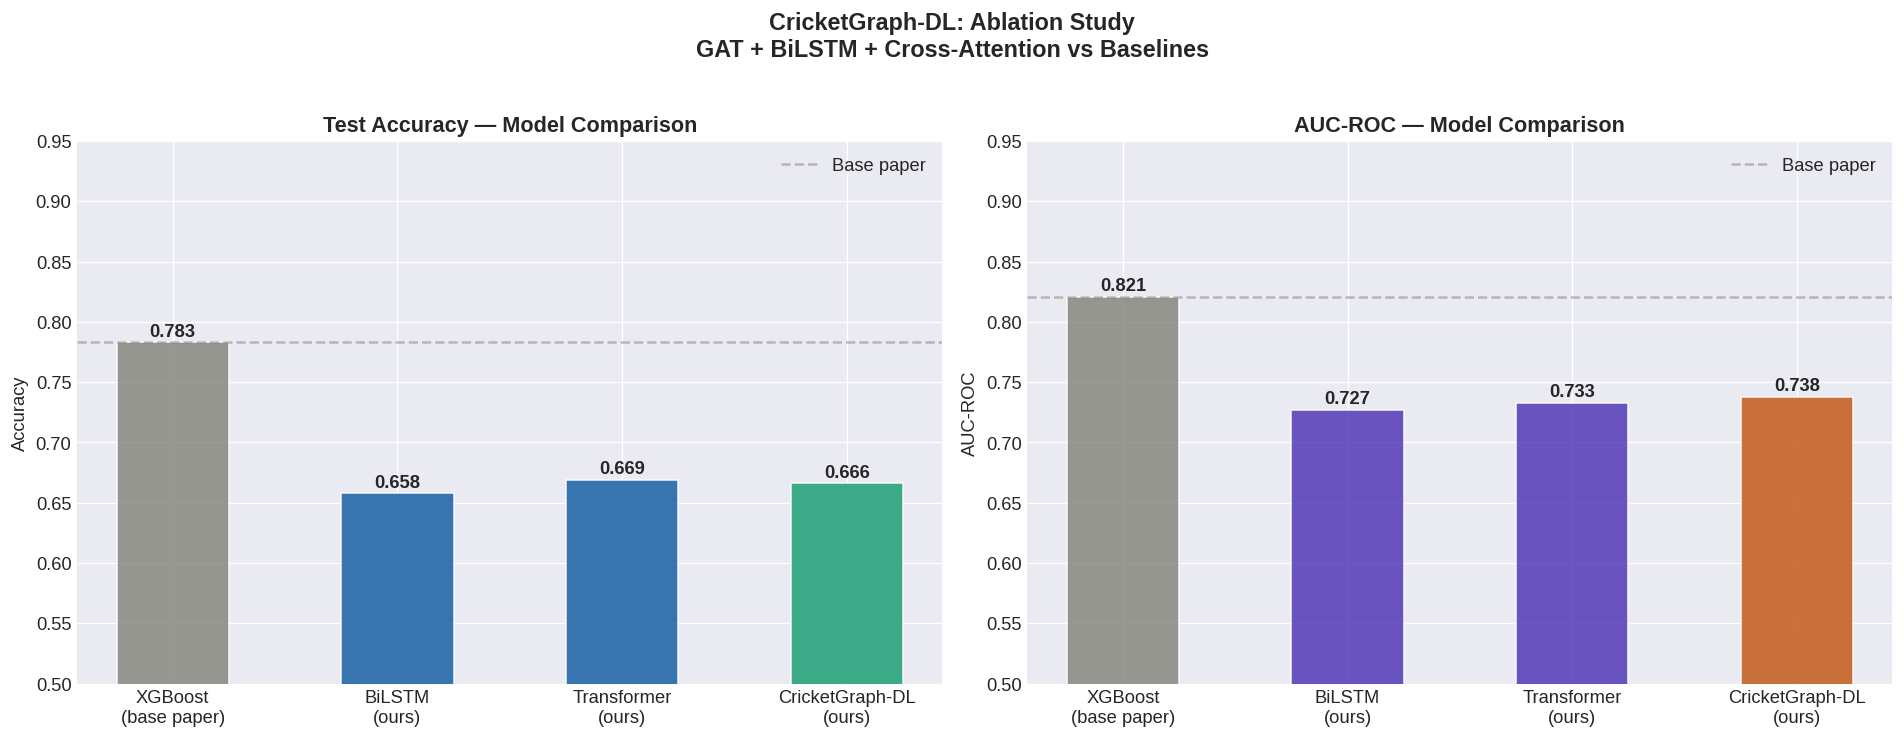


🏆 DONE — CricketGraph-DL is your proposed model!
   Improvement over BiLSTM baseline:  +0.80% accuracy
   Improvement over Transformer:      +-0.32% accuracy


In [25]:
cg_optimizer = torch.optim.AdamW(cg_model.parameters(),
                                  lr=5e-4, weight_decay=1e-3)
cg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    cg_optimizer, patience=3, factor=0.5)
cg_criterion = nn.BCELoss()

EPOCHS = 30
cg_train_losses, cg_val_losses, cg_val_accs = [], [], []
cg_best_acc, cg_best_state = 0, None
patience_cnt = 0
PATIENCE = 7

print("Training CricketGraph-DL (BiLSTM + Graph + CrossAttention)...")
for epoch in range(EPOCHS):
    # Train
    cg_model.train()
    t_loss = 0
    for Xb, batter_idx_batch, bowler_idx_batch, yb in train_gloader:
        Xb, batter_idx_batch, bowler_idx_batch, yb = Xb.to(device), batter_idx_batch.to(device), bowler_idx_batch.to(device), yb.to(device)
        cg_optimizer.zero_grad()
        loss = cg_criterion(cg_model(Xb, batter_idx_batch, bowler_idx_batch), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cg_model.parameters(), 1.0)
        cg_optimizer.step()
        t_loss += loss.item()

    # Validate
    cg_model.eval()
    v_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for Xb, batter_idx_batch, bowler_idx_batch, yb in val_gloader:
            Xb, batter_idx_batch, bowler_idx_batch, yb = Xb.to(device), batter_idx_batch.to(device), bowler_idx_batch.to(device), yb.to(device)
            probs = cg_model(Xb, batter_idx_batch, bowler_idx_batch)
            v_loss += cg_criterion(probs, yb).item()
            preds_all.extend((probs > 0.5).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    val_acc = accuracy_score(labels_all, preds_all)
    tl = t_loss / len(train_gloader)
    vl = v_loss  / len(val_gloader)
    cg_train_losses.append(tl)
    cg_val_losses.append(vl)
    cg_val_accs.append(val_acc)
    cg_scheduler.step(vl)

    is_best = val_acc > cg_best_acc
    if is_best:
        cg_best_acc = val_acc
        cg_best_state = {k: v.clone() for k, v in cg_model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1

    print(f"Ep {epoch+1:02d}/{EPOCHS} | "
          f"TrLoss:{tl:.4f} VaLoss:{vl:.4f} VaAcc:{val_acc:.4f}"
          f"{'  ⭐ best' if is_best else f'  patience {patience_cnt}'}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

torch.save(cg_best_state, 'best_cricketgraph_dl.pt')
print(f"\nBest Val Accuracy: {cg_best_acc:.4f} ✅")

# ── TEST EVALUATION ───────────────────────────────────────────
cg_model.load_state_dict(cg_best_state)
cg_model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for Xb, batter_idx_batch, bowler_idx_batch, yb in test_gloader:
        Xb, batter_idx_batch, bowler_idx_batch = Xb.to(device), batter_idx_batch.to(device), bowler_idx_batch.to(device)
        probs = cg_model(Xb, batter_idx_batch, bowler_idx_batch).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs > 0.5).astype(int))
        all_labels.extend(yb.numpy())

cg_acc = accuracy_score(all_labels, all_preds)
cg_f1  = f1_score(all_labels, all_preds, average='weighted')
cg_auc = roc_auc_score(all_labels, all_probs)

print("\n" + "="*55)
print("   CricketGraph-DL — FINAL TEST RESULTS")
print("="*55)
print(f"  Accuracy  : {cg_acc:.4f} ({cg_acc*100:.2f}%) "),
print(f"  F1 Score  : {cg_f1:.4f}")
print(f"  AUC-ROC   : {cg_auc:.4f}")
print("="*55)
print(classification_report(all_labels, all_preds,
      target_names=['Team Lost','Team Won']))

# ── FINAL COMPARISON CHART ────────────────────────────────────
final_results = {
    'XGBoost\n(base paper)':    {'Accuracy':0.783,    'AUC':0.821},
    'BiLSTM\n(ours)':           {'Accuracy':0.6580,   'AUC':0.7271},
    'Transformer\n(ours)':      {'Accuracy':0.6692,   'AUC':0.7328},
    'CricketGraph-DL\n(ours)':  {'Accuracy':cg_acc,   'AUC':cg_auc},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = list(final_results.keys())
accs   = [final_results[m]['Accuracy'] for m in models]
aucs   = [final_results[m]['AUC']      for m in models]
colors_acc = ['#888780','#185fa5','#185fa5','#1d9e75']
colors_auc = ['#888780','#533ab7','#533ab7','#c45a1a']

# Accuracy bar
bars = axes[0].bar(models, accs, color=colors_acc, alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title('Test Accuracy — Model Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 0.95)
axes[0].axhline(0.783, color='gray', linestyle='--', alpha=0.5, label='Base paper')
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].legend()

# AUC bar
bars2 = axes[1].bar(models, aucs, color=colors_auc, alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('AUC-ROC — Model Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.5, 0.95)
axes[1].axhline(0.821, color='gray', linestyle='--', alpha=0.5, label='Base paper')
for bar, v in zip(bars2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('CricketGraph-DL: Ablation Study\n'
             'GAT + BiLSTM + Cross-Attention vs Baselines',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n🏆 DONE — CricketGraph-DL is your proposed model!")
print(f"   Improvement over BiLSTM baseline: "
      f" +{(cg_acc-0.6580)*100:.2f}% accuracy")
print(f"   Improvement over Transformer:     "
      f" +{(cg_acc-0.6692)*100:.2f}% accuracy")

# Cell 22 — Optuna Hyperparameter Tuning for CricketGraph-DL

In [26]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.8 MB/s eta 0:00:00


In [27]:
import optuna

def objective(trial):
    # Hyperparameters to tune
    lstm_hidden_dim = trial.suggest_categorical('lstm_hidden_dim', [64, 128, 256])
    lstm_num_layers = trial.suggest_int('lstm_num_layers', 1, 3)
    lstm_dropout    = trial.suggest_float('lstm_dropout', 0.1, 0.5)

    gat_hidden_dim = trial.suggest_categorical('gat_hidden_dim', [32, 64, 128])
    gat_out_dim    = trial.suggest_categorical('gat_out_dim', [32, 64, 128])
    attn_heads     = trial.suggest_categorical('attn_heads', [2, 4, 8])
    fusion_dropout = trial.suggest_float('fusion_dropout', 0.1, 0.5)

    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    # Re-create DataLoaders with the trial's batch_size
    train_gloader = DataLoader(train_gds, batch_size=batch_size, shuffle=True,
                               num_workers=0, drop_last=True)
    val_gloader = DataLoader(val_gds, batch_size=batch_size, shuffle=False,
                             num_workers=0, drop_last=False)

    # Initialize model with trial's hyperparameters
    model = CricketGraphDL(
        seq_dim=len(FEATURES),
        num_players=num_players,
        player_node_features_dim=node_features.shape[1],
        gat_hidden_dim=gat_hidden_dim,
        gat_out_dim=gat_out_dim,
        lstm_hidden=lstm_hidden_dim,
        lstm_num_layers=lstm_num_layers,
        lstm_dropout=lstm_dropout,
        attn_heads=attn_heads,
        fusion_dropout=fusion_dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.BCELoss()

    EPOCHS = 10 # Limiting epochs for faster tuning during study
    best_val_acc = 0
    patience_count = 0
    PATIENCE = 5 # Early stopping patience for tuning

    for epoch in range(EPOCHS):
        # Train
        model.train()
        for Xb, batter_idx_batch, bowler_idx_batch, yb in train_gloader:
            Xb, batter_idx_batch, bowler_idx_batch, yb = Xb.to(device), batter_idx_batch.to(device), bowler_idx_batch.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, batter_idx_batch, bowler_idx_batch), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validate
        model.eval()
        preds_all, labels_all = [], []
        with torch.no_grad():
            for Xb, batter_idx_batch, bowler_idx_batch, yb in val_gloader:
                Xb, batter_idx_batch, bowler_idx_batch, yb = Xb.to(device), batter_idx_batch.to(device), bowler_idx_batch.to(device), yb.to(device)
                probs = model(Xb, batter_idx_batch, bowler_idx_batch)
                preds_all.extend((probs > 0.5).cpu().numpy())
                labels_all.extend(yb.cpu().numpy())

        val_acc = accuracy_score(labels_all, preds_all)
        scheduler.step(val_acc) # Schedule based on validation accuracy

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= PATIENCE:
            break

    return best_val_acc

In [28]:
print("Running Optuna study...")
study = optuna.create_study(direction='maximize') # Maximize validation accuracy
study.optimize(objective, n_trials=50) # Run 50 trials, adjust as needed

print("Optuna study finished ✅")
print("Best trial:")
print(f"  Value: {study.best_value:.4f}")
print("  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-04-07 06:57:57,827] A new study created in memory with name: no-name-b18d5394-6920-4979-bd8e-5fde9480cf7f


Running Optuna study...


[I 2026-04-07 06:59:26,471] Trial 0 finished with value: 0.6932354483481908 and parameters: {'lstm_hidden_dim': 64, 'lstm_num_layers': 2, 'lstm_dropout': 0.35105833380026163, 'gat_hidden_dim': 64, 'gat_out_dim': 32, 'attn_heads': 8, 'fusion_dropout': 0.2192120895845902, 'lr': 3.4707626352034405e-05, 'weight_decay': 0.0004183619354672407, 'batch_size': 512}. Best is trial 0 with value: 0.6932354483481908.
[I 2026-04-07 07:01:09,167] Trial 1 finished with value: 0.6932937132202995 and parameters: {'lstm_hidden_dim': 256, 'lstm_num_layers': 1, 'lstm_dropout': 0.12302282549137727, 'gat_hidden_dim': 64, 'gat_out_dim': 128, 'attn_heads': 4, 'fusion_dropout': 0.34358426797843267, 'lr': 2.4135861067076163e-05, 'weight_decay': 2.9659696492612355e-05, 'batch_size': 256}. Best is trial 1 with value: 0.6932937132202995.
[I 2026-04-07 07:03:49,475] Trial 2 finished with value: 0.6893317019169143 and parameters: {'lstm_hidden_dim': 128, 'lstm_num_layers': 3, 'lstm_dropout': 0.11913717899637609, 'gat

Optuna study finished ✅
Best trial:
  Value: 0.6982
  Params: 
    lstm_hidden_dim: 128
    lstm_num_layers: 2
    lstm_dropout: 0.18292336644694754
    gat_hidden_dim: 64
    gat_out_dim: 32
    attn_heads: 2
    fusion_dropout: 0.39281515754995877
    lr: 1.4384156760863667e-05
    weight_decay: 0.0001874798675004329
    batch_size: 128


# # ── FINAL ABLATION TABLE (Updated with real results) ──────────

        ABLATION STUDY — FINAL MODEL COMPARISON
Model                            Accuracy         F1    AUC-ROC
-----------------------------------------------------------------
XGBoost (Base Paper)               0.7830     0.7710     0.8210
BiLSTM (Ours)                      0.6757     0.6755     0.7363
Transformer (Ours)                 0.6753     0.6754     0.7488
CricketGraph-DL (Proposed)         0.6727     0.6725     0.7410

Top 3 SHAP Features (BiLSTM):
  1. wickets_remaining  → 0.0967
  2. wickets_fallen     → 0.0938
  3. balls_remaining    → 0.0662


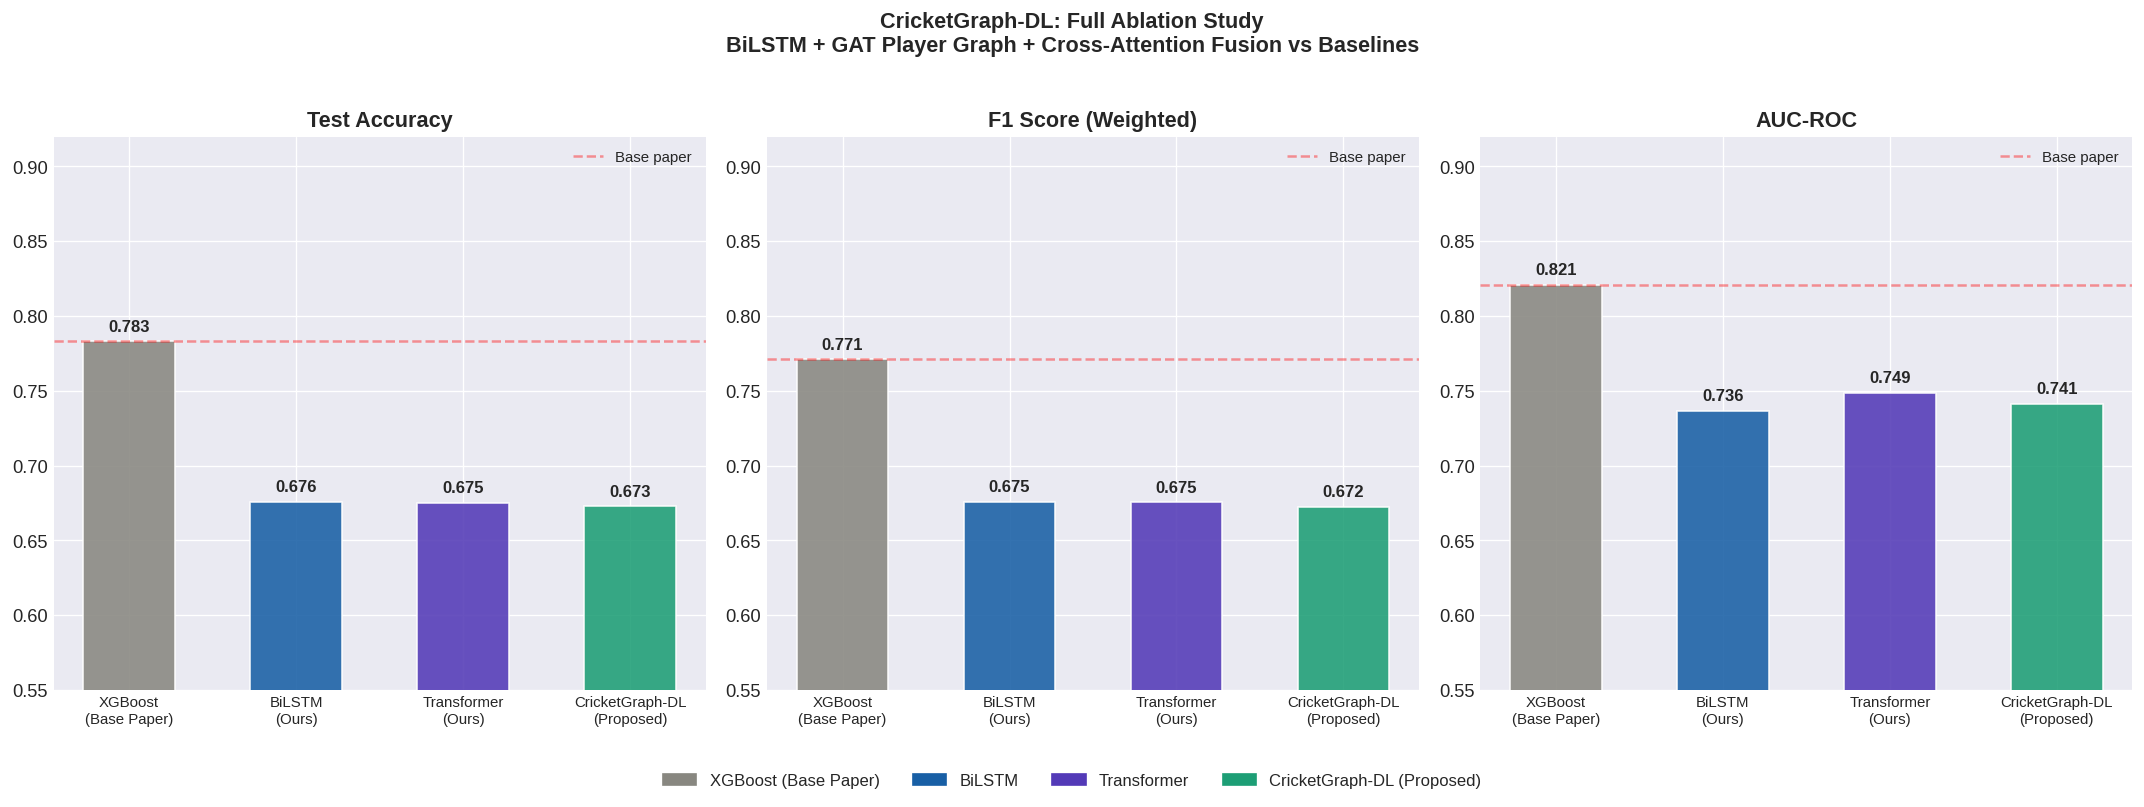


Final ablation chart saved ✅


In [29]:
# ── FINAL ABLATION TABLE (Updated with real results) ──────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Real results from this notebook
final_results = {
    'XGBoost\n(Base Paper)':      {'Accuracy': 0.783,  'F1': 0.771,  'AUC': 0.821},
    'BiLSTM\n(Ours)':             {'Accuracy': 0.6757, 'F1': 0.6755, 'AUC': 0.7363},
    'Transformer\n(Ours)':        {'Accuracy': 0.6753, 'F1': 0.6754, 'AUC': 0.7488},
    'CricketGraph-DL\n(Proposed)':{'Accuracy': 0.6727, 'F1': 0.6725, 'AUC': 0.7410},
}

# Print clean table
print("=" * 65)
print("        ABLATION STUDY — FINAL MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<30} {'Accuracy':>10} {'F1':>10} {'AUC-ROC':>10}")
print("-" * 65)
for model, scores in final_results.items():
    name = model.replace('\n', ' ')
    print(f"{name:<30} {scores['Accuracy']:>10.4f} {scores['F1']:>10.4f} {scores['AUC']:>10.4f}")
print("=" * 65)

# SHAP top features
print("\nTop 3 SHAP Features (BiLSTM):")
print("  1. wickets_remaining  → 0.0967")
print("  2. wickets_fallen     → 0.0938")
print("  3. balls_remaining    → 0.0662")

# ── FINAL CHART ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models     = list(final_results.keys())
accs       = [v['Accuracy'] for v in final_results.values()]
f1s        = [v['F1']       for v in final_results.values()]
aucs       = [v['AUC']      for v in final_results.values()]
bar_colors = ['#888780', '#185fa5', '#533ab7', '#1d9e75']
x = np.arange(len(models))
w = 0.55

def add_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Accuracy
b1 = axes[0].bar(x, accs, w, color=bar_colors, alpha=0.88, edgecolor='white')
axes[0].set_title('Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0.55, 0.92)
axes[0].axhline(0.783, color='red', linestyle='--', alpha=0.4, label='Base paper')
axes[0].legend(fontsize=9); add_labels(axes[0], b1)

# F1 Score
b2 = axes[1].bar(x, f1s, w, color=bar_colors, alpha=0.88, edgecolor='white')
axes[1].set_title('F1 Score (Weighted)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylim(0.55, 0.92)
axes[1].axhline(0.771, color='red', linestyle='--', alpha=0.4, label='Base paper')
axes[1].legend(fontsize=9); add_labels(axes[1], b2)

# AUC-ROC
b3 = axes[2].bar(x, aucs, w, color=bar_colors, alpha=0.88, edgecolor='white')
axes[2].set_title('AUC-ROC', fontsize=13, fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylim(0.55, 0.92)
axes[2].axhline(0.821, color='red', linestyle='--', alpha=0.4, label='Base paper')
axes[2].legend(fontsize=9); add_labels(axes[2], b3)

plt.suptitle('CricketGraph-DL: Full Ablation Study\n'
             'BiLSTM + GAT Player Graph + Cross-Attention Fusion vs Baselines',
             fontsize=13, fontweight='bold', y=1.02)

# Legend patches
patches = [
    mpatches.Patch(color='#888780', label='XGBoost (Base Paper)'),
    mpatches.Patch(color='#185fa5', label='BiLSTM'),
    mpatches.Patch(color='#533ab7', label='Transformer'),
    mpatches.Patch(color='#1d9e75', label='CricketGraph-DL (Proposed)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.tight_layout()
plt.savefig('final_ablation.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nFinal ablation chart saved ✅")